# Bank Customer Churn Prediction Using Deep Learning

A complete, portfolio-ready Jupyter Notebook for predicting bank customer churn with exploratory data analysis, visualization, preprocessing, a Logistic Regression baseline, and a TensorFlow/Keras Artificial Neural Network.

**Target:** `Exited`  
**0:** Customer stayed  
**1:** Customer exited / churned  

The notebook is intentionally split into small, detailed cells so each stage can be understood, executed, and debugged independently.

## 1. Project Overview

Customer churn prediction is a binary classification problem. The objective is to learn patterns in customer demographics, account behavior, product usage, and financial attributes that are associated with a customer's decision to leave the bank.

The workflow is:

1. Load and inspect the dataset
2. Validate data quality
3. Remove identifier columns
4. Explore churn patterns
5. Visualize numerical and categorical relationships
6. Encode categorical variables
7. Split the data with stratification
8. Scale features using training data only
9. Train a Logistic Regression baseline
10. Train a deep neural network with TensorFlow/Keras
11. Evaluate with accuracy, precision, recall, F1, ROC-AUC and PR-AUC
12. Tune the classification threshold
13. Analyze permutation feature importance
14. Build a reusable customer-risk prediction function


## 2. Environment and Library Setup

Use a Python environment with Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow, and IPython available.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.dpi": 120
})

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


## 3. Load the Dataset

The CSV is expected to be in the same folder as this notebook. The loader checks several common filenames so the notebook is convenient in Jupyter, VS Code, and local project folders.

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,"101,348.880",1
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.860",1,0,1,"112,542.580",0
2,3,15619304,Onio,502,France,Female,42,8,"159,660.800",3,1,0,"113,931.570",1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,"93,826.630",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.820",1,1,1,"79,084.100",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.000,2,1,0,"96,270.640",0
9996,9997,15569892,Johnstone,516,France,Male,35,10,"57,369.610",1,1,1,"101,699.770",0
9997,9998,15584532,Liu,709,France,Female,36,7,0.000,1,0,1,"42,085.580",1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,"75,075.310",2,1,0,"92,888.520",1


In [3]:
print("Last five rows")
display(df.tail())

print("Column names")
display(pd.Series(df.columns, name="Column"))

print("Dataset information")
df.info()

Last five rows


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.000,2,1,0,"96,270.640",0
9996,9997,15569892,Johnstone,516,France,Male,35,10,"57,369.610",1,1,1,"101,699.770",0
9997,9998,15584532,Liu,709,France,Female,36,7,0.000,1,0,1,"42,085.580",1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,"75,075.310",2,1,0,"92,888.520",1
9999,10000,15628319,Walker,792,France,Female,28,4,"130,142.790",1,1,0,"38,190.780",0


Column names


,Column
0,RowNumber
1,CustomerId
2,Surname
3,CreditScore
4,Geography
5,Gender
6,Age
7,Tenure
8,Balance
9,NumOfProducts


Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## 4. Data Quality Audit

This section checks missing values, duplicate records, data types, cardinality, and summary statistics before any modeling begins.

In [4]:
quality = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing %": (df.isna().sum().values / len(df) * 100),
    "Unique Values": df.nunique().values
})

display(quality)
print("Duplicate rows:", df.duplicated().sum())

,Column,Data Type,Missing Values,Missing %,Unique Values
0,RowNumber,int64,0,0.000,10000
1,CustomerId,int64,0,0.000,10000
2,Surname,object,0,0.000,2932
3,CreditScore,int64,0,0.000,460
4,Geography,object,0,0.000,3
5,Gender,object,0,0.000,2
6,Age,int64,0,0.000,70
7,Tenure,int64,0,0.000,11
8,Balance,float64,0,0.000,6382
9,NumOfProducts,int64,0,0.000,4


Duplicate rows: 0


In [5]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,"10,000.000",NaN,NaN,NaN,"5,000.500","2,886.896",1.000,"2,500.750","5,000.500","7,500.250","10,000.000"
CustomerId,"10,000.000",NaN,NaN,NaN,"15,690,940.569","71,936.186","15,565,701.000","15,628,528.250","15,690,738.000","15,753,233.750","15,815,690.000"
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,"10,000.000",NaN,NaN,NaN,650.529,96.653,350.000,584.000,652.000,718.000,850.000
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,"10,000.000",NaN,NaN,NaN,38.922,10.488,18.000,32.000,37.000,44.000,92.000
Tenure,"10,000.000",NaN,NaN,NaN,5.013,2.892,0.000,3.000,5.000,7.000,10.000
Balance,"10,000.000",NaN,NaN,NaN,"76,485.889","62,397.405",0.000,0.000,"97,198.540","127,644.240","250,898.090"
NumOfProducts,"10,000.000",NaN,NaN,NaN,1.530,0.582,1.000,1.000,1.000,2.000,4.000


## 5. Validate Expected Columns and Ranges

The dataset should contain customer identifiers, demographic variables, account features, and the `Exited` target. Range checks help detect obvious data-quality problems without blindly deleting observations.


In [6]:
expected_columns = [
    "RowNumber", "CustomerId", "Surname", "CreditScore", "Geography", "Gender",
    "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard",
    "IsActiveMember", "EstimatedSalary", "Exited"
]

missing_expected = [column for column in expected_columns if column not in df.columns]
extra_columns = [column for column in df.columns if column not in expected_columns]

print("Missing expected columns:", missing_expected)
print("Additional columns:", extra_columns)

numeric_checks = pd.DataFrame({
    "Minimum": df[["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]].min(),
    "Maximum": df[["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]].max(),
    "Mean": df[["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]].mean()
})

display(numeric_checks)
print("Geography values:", sorted(df["Geography"].dropna().unique()))
print("Gender values:", sorted(df["Gender"].dropna().unique()))
print("Exited values:", sorted(df["Exited"].dropna().unique()))

Missing expected columns: []
Additional columns: []


,Minimum,Maximum,Mean
CreditScore,350.000,850.000,650.529
Age,18.000,92.000,38.922
Tenure,0.000,10.000,5.013
Balance,0.000,"250,898.090","76,485.889"
NumOfProducts,1.000,4.000,1.530
EstimatedSalary,11.580,"199,992.480","100,090.240"


Geography values: ['France', 'Germany', 'Spain']
Gender values: ['Female', 'Male']
Exited values: [np.int64(0), np.int64(1)]


## 6. Remove Identifier Columns

`RowNumber`, `CustomerId`, and `Surname` identify customers but do not represent the behavioral variables we want the neural network to learn from. They are removed before feature engineering.


In [7]:
df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"], errors="ignore").copy()

display(df_model.head())
print("Modeling dataset shape:", df_model.shape)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.000,1,1,1,"101,348.880",1
1,608,Spain,Female,41,1,"83,807.860",1,0,1,"112,542.580",0
2,502,France,Female,42,8,"159,660.800",3,1,0,"113,931.570",1
3,699,France,Female,39,1,0.000,2,0,0,"93,826.630",0
4,850,Spain,Female,43,2,"125,510.820",1,1,1,"79,084.100",0


Modeling dataset shape: (10000, 11)


## 7. Target Variable Analysis

Churn datasets are commonly imbalanced, so the first modeling question is not only how many customers left, but also how large the minority class is.

In [8]:
target_counts = df_model["Exited"].value_counts().sort_index()
target_percent = df_model["Exited"].value_counts(normalize=True).sort_index().mul(100)

target_summary = pd.DataFrame({
    "Status": ["Stayed", "Exited"],
    "Customers": [target_counts.get(0, 0), target_counts.get(1, 0)],
    "Percentage": [target_percent.get(0, 0), target_percent.get(1, 0)]
})

display(target_summary)

,Status,Customers,Percentage
0,Stayed,7963,79.630
1,Exited,2037,20.370


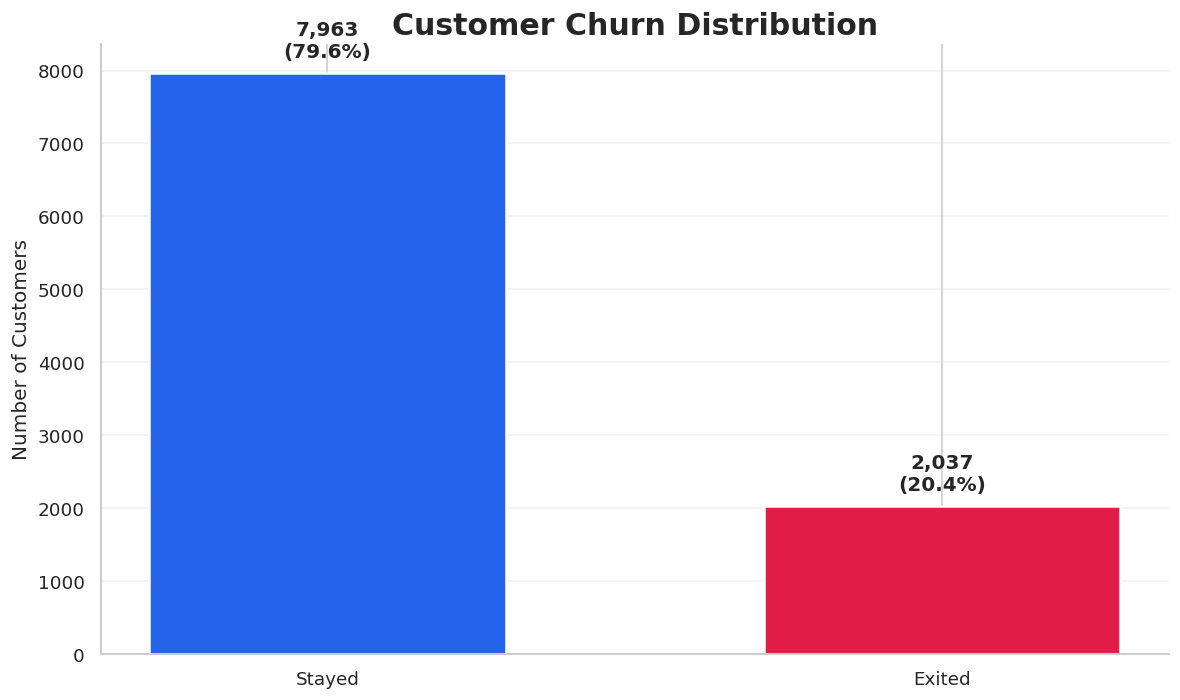

In [9]:
labels = ["Stayed", "Exited"]
values = [target_counts.get(0, 0), target_counts.get(1, 0)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, width=0.58, color=["#2563EB", "#E11D48"], edgecolor="white", linewidth=1.5)
ax.set_title("Customer Churn Distribution")
ax.set_ylabel("Number of Customers")
ax.grid(axis="y", alpha=0.25)

for bar, count, pct in zip(bars, values, [target_percent.get(0, 0), target_percent.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.02, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

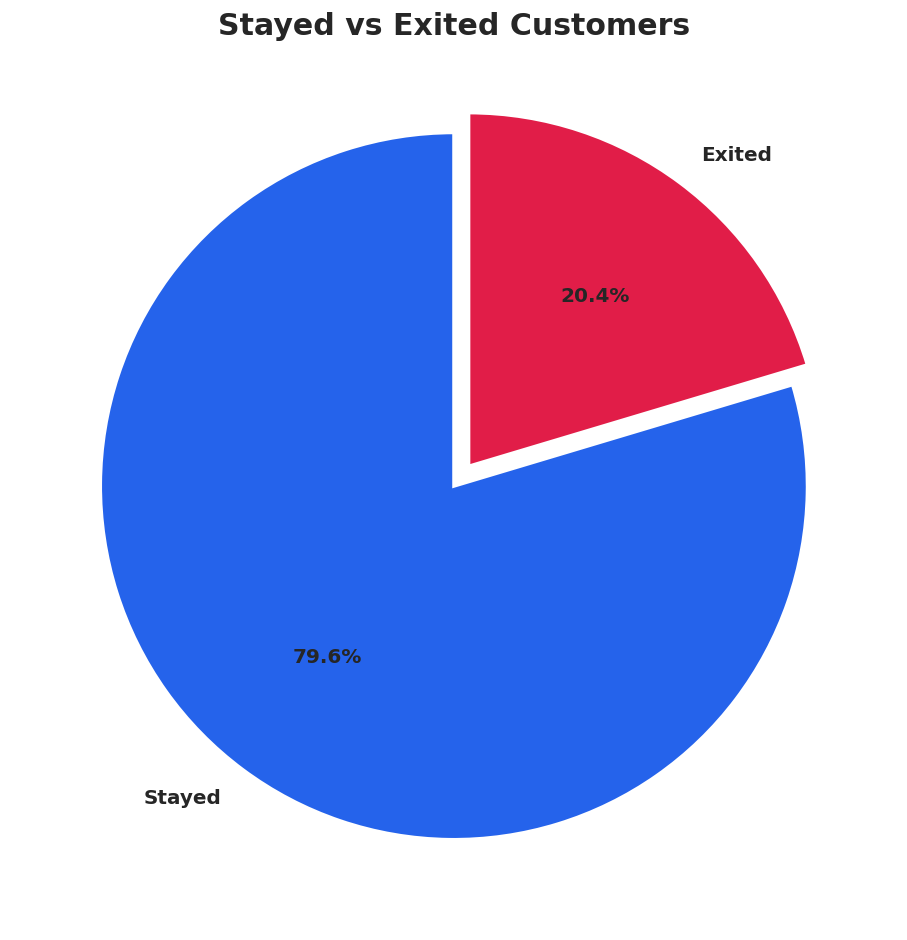

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.07),
    colors=["#2563EB", "#E11D48"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12, "fontweight": "bold"}
)
ax.set_title("Stayed vs Exited Customers")
plt.tight_layout()
plt.show()

## 8. Geography and Gender Churn Analysis

The goal here is to compare **churn rates**, not only raw customer counts. A group with fewer customers can still have a much higher churn rate.


In [11]:
geo_summary = df_model.groupby("Geography")["Exited"].agg(Customers="size", Exited="sum")
geo_summary["Churn Rate (%)"] = geo_summary["Exited"] / geo_summary["Customers"] * 100
geo_summary = geo_summary.sort_values("Churn Rate (%)", ascending=False)
display(geo_summary)


,Customers,Exited,Churn Rate (%)
Geography,,,
Germany,2509,814,32.443
Spain,2477,413,16.673
France,5014,810,16.155


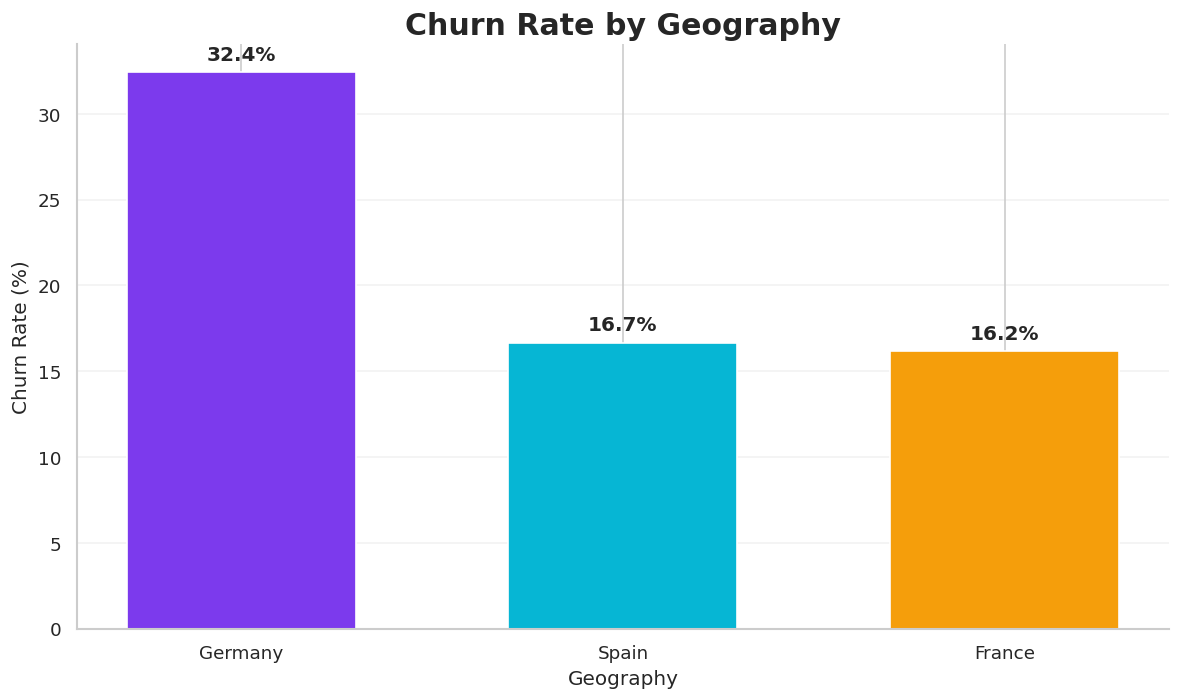

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(geo_summary.index, geo_summary["Churn Rate (%)"], color=["#7C3AED", "#06B6D4", "#F59E0B"], width=0.6)
ax.set_title("Churn Rate by Geography")
ax.set_xlabel("Geography")
ax.set_ylabel("Churn Rate (%)")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, geo_summary["Churn Rate (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.7, f"{value:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [13]:
gender_summary = df_model.groupby("Gender")["Exited"].agg(Customers="size", Exited="sum")
gender_summary["Churn Rate (%)"] = gender_summary["Exited"] / gender_summary["Customers"] * 100
gender_summary = gender_summary.sort_values("Churn Rate (%)", ascending=False)
display(gender_summary)

,Customers,Exited,Churn Rate (%)
Gender,,,
Female,4543,1139,25.072
Male,5457,898,16.456


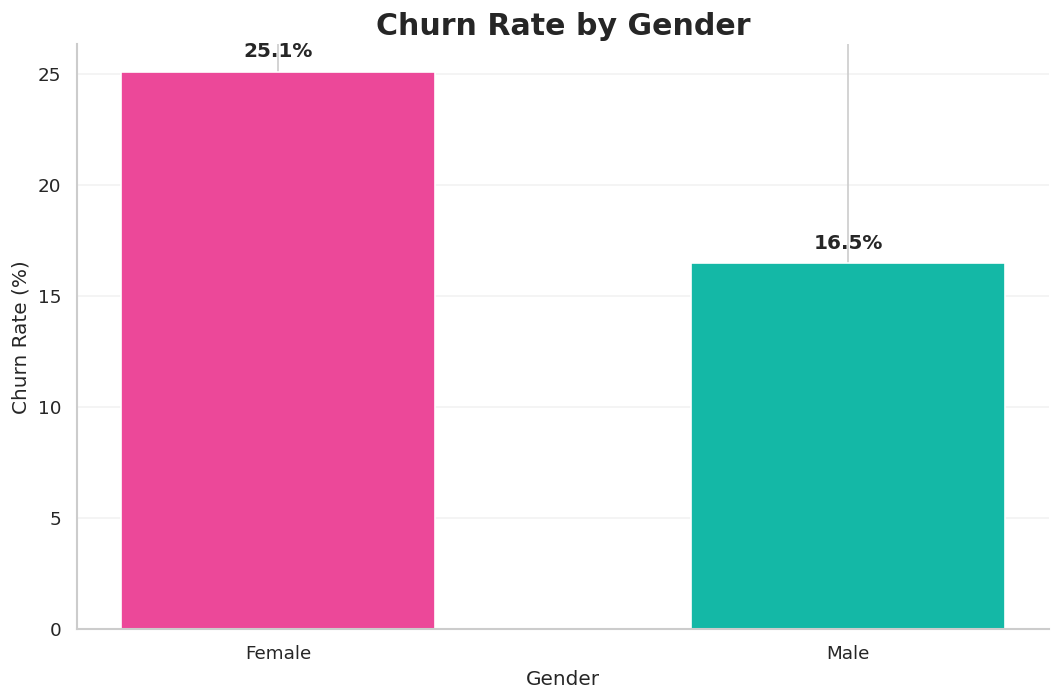

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(gender_summary.index, gender_summary["Churn Rate (%)"], color=["#EC4899", "#14B8A6"], width=0.55)
ax.set_title("Churn Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Churn Rate (%)")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, gender_summary["Churn Rate (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.7, f"{value:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


## 9. Numerical Feature Distributions

These distributions show scale, concentration, skewness, and the presence of potential extreme values before standardization.

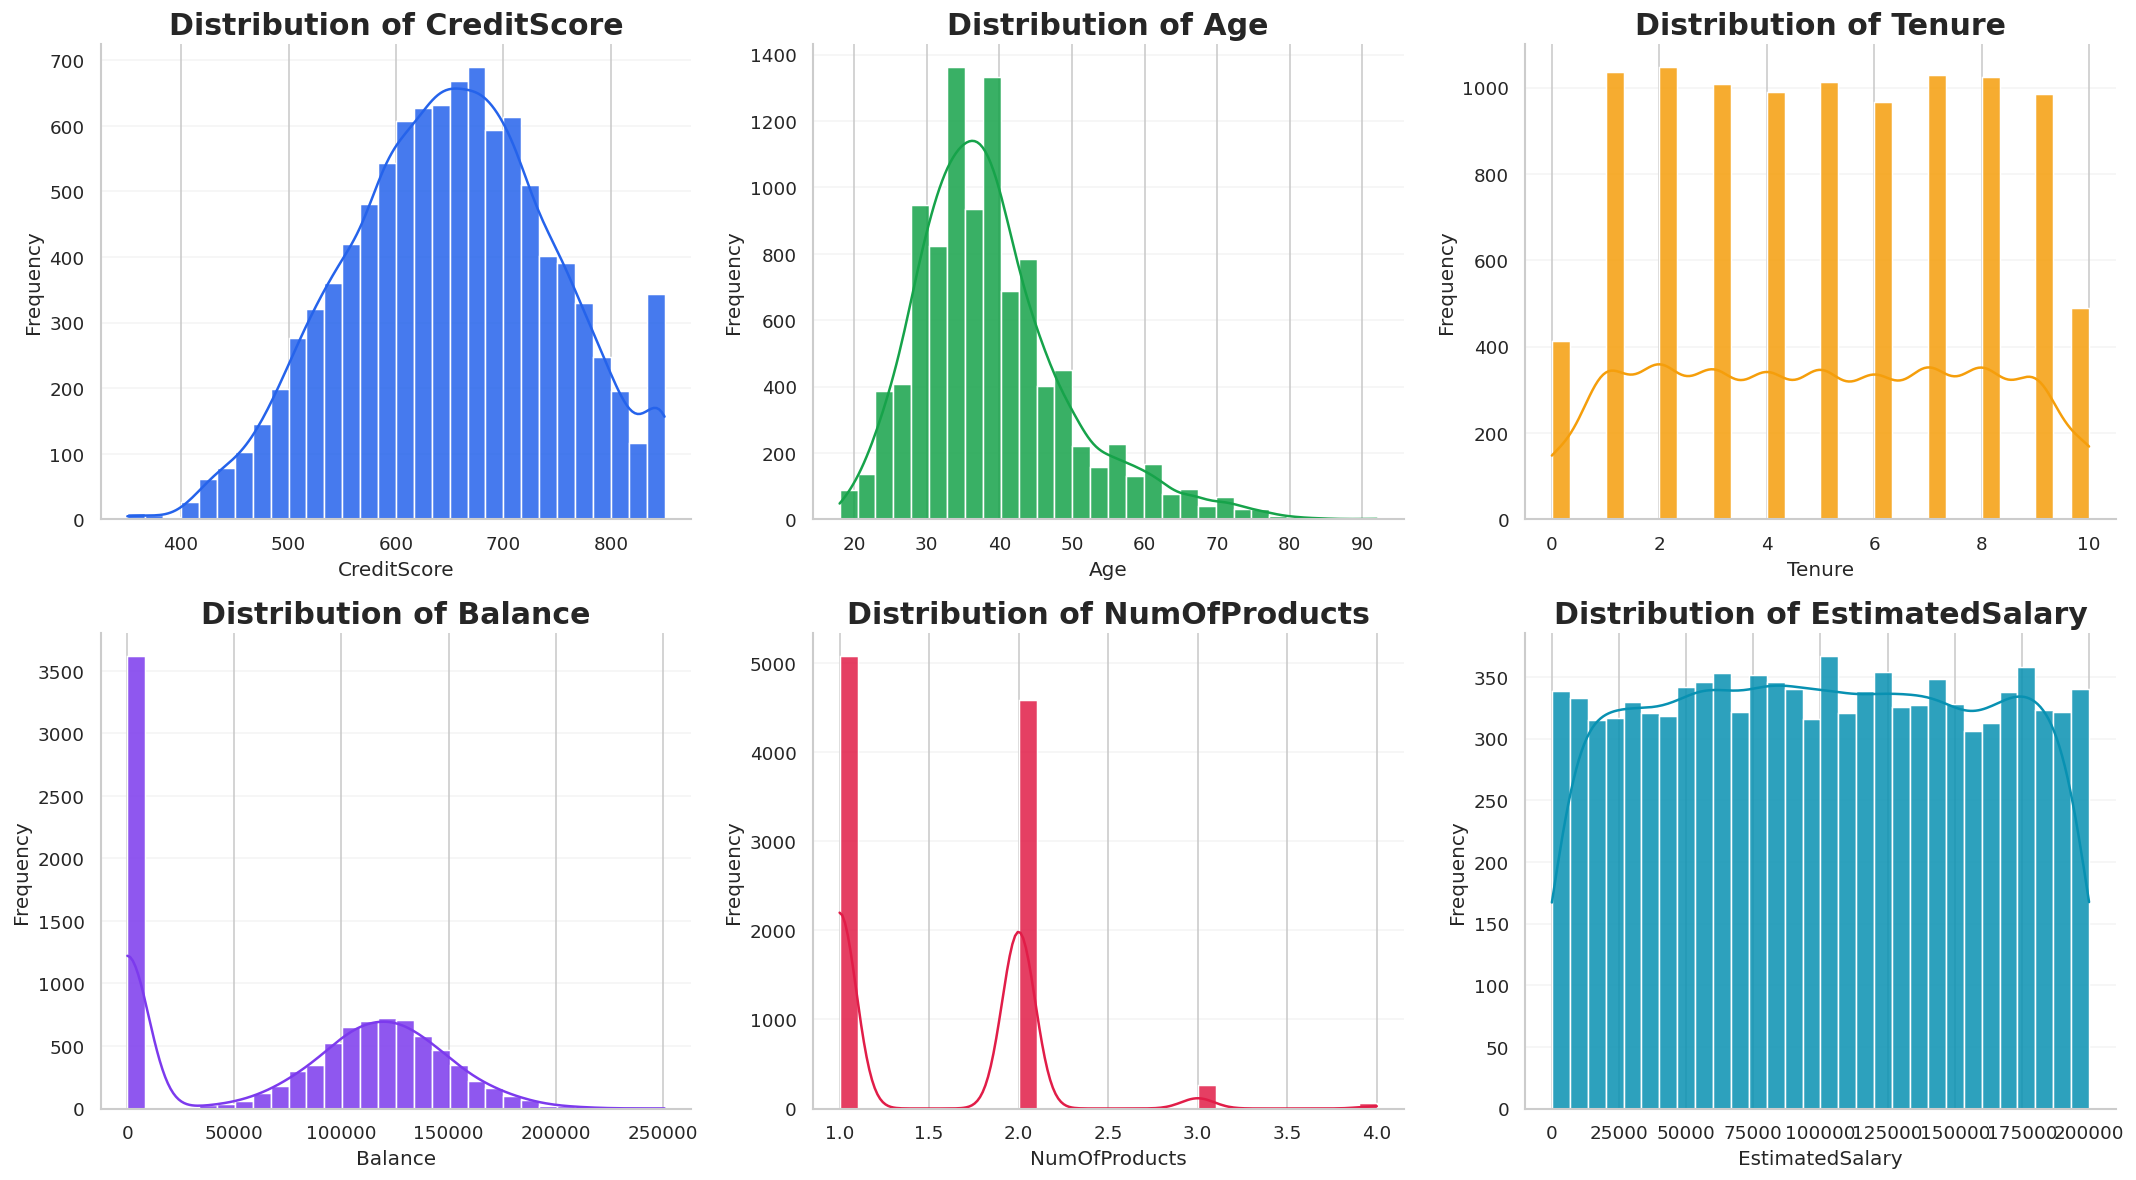

In [15]:
numeric_columns = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_colors = ["#2563EB", "#16A34A", "#F59E0B", "#7C3AED", "#E11D48", "#0891B2"]

for ax, column, color in zip(axes.flat, numeric_columns, plot_colors):
    sns.histplot(df_model[column], bins=30, kde=True, ax=ax, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 10. Churn vs Age, Balance and Credit Score

These plots compare the feature distributions for customers who stayed versus customers who exited. They are useful for identifying visible shifts between the two classes.

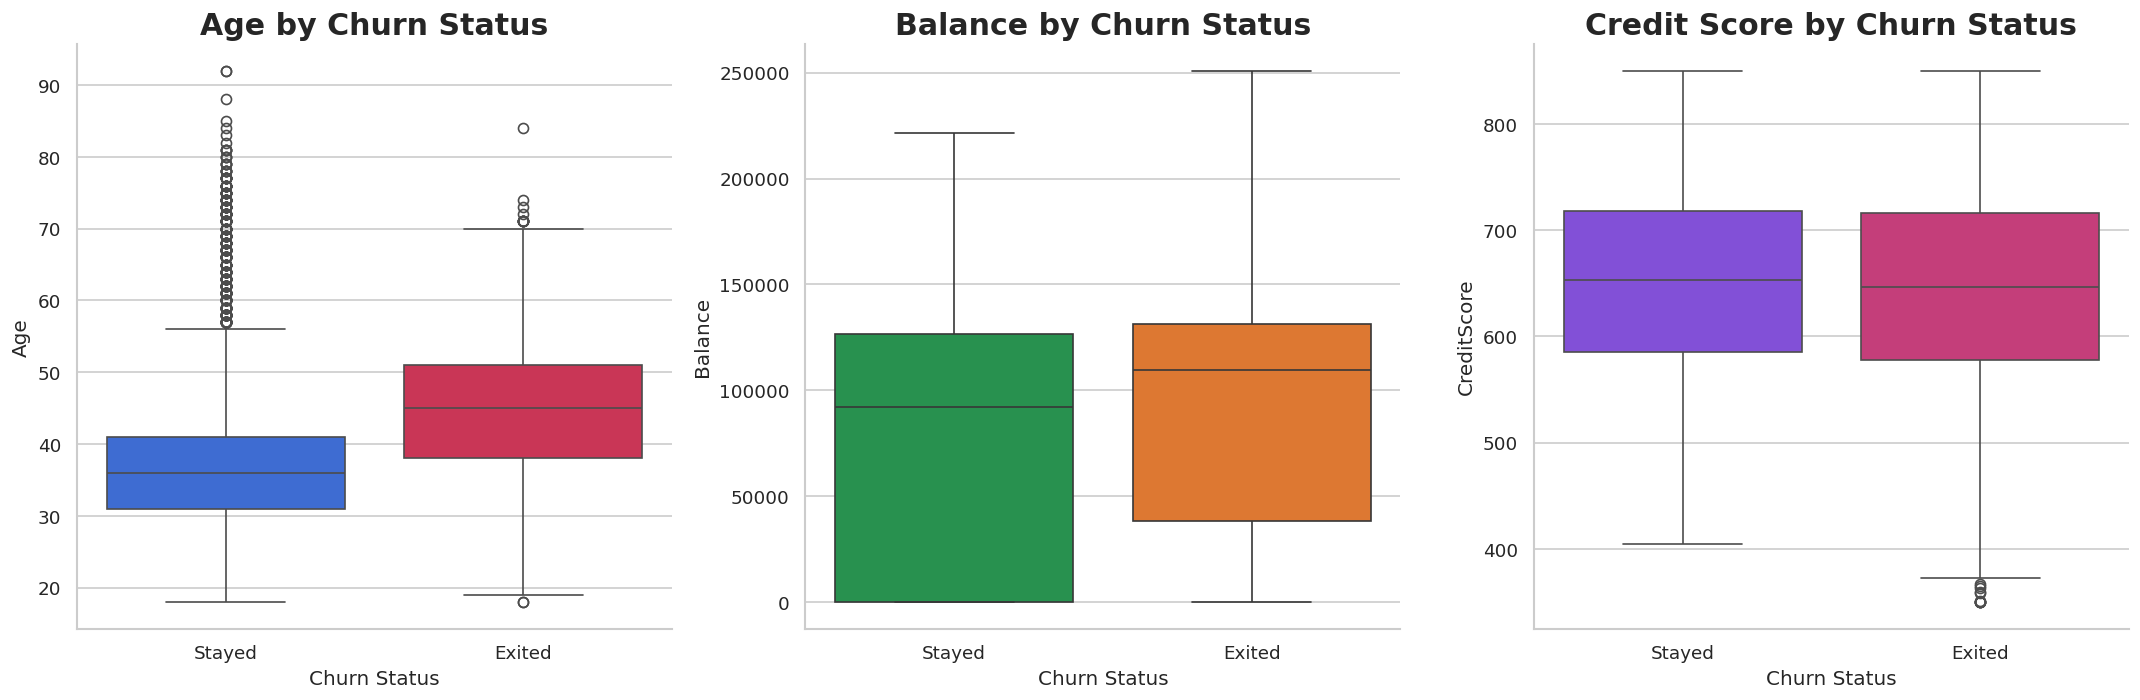

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df_model, x="Exited", y="Age", ax=axes[0], hue="Exited", palette=["#2563EB", "#E11D48"], legend=False)
axes[0].set_title("Age by Churn Status")
axes[0].set_xticklabels(["Stayed", "Exited"])
axes[0].set_xlabel("Churn Status")

sns.boxplot(data=df_model, x="Exited", y="Balance", ax=axes[1], hue="Exited", palette=["#16A34A", "#F97316"], legend=False)
axes[1].set_title("Balance by Churn Status")
axes[1].set_xticklabels(["Stayed", "Exited"])
axes[1].set_xlabel("Churn Status")

sns.boxplot(data=df_model, x="Exited", y="CreditScore", ax=axes[2], hue="Exited", palette=["#7C3AED", "#DB2777"], legend=False)
axes[2].set_title("Credit Score by Churn Status")
axes[2].set_xticklabels(["Stayed", "Exited"])
axes[2].set_xlabel("Churn Status")

plt.tight_layout()
plt.show()

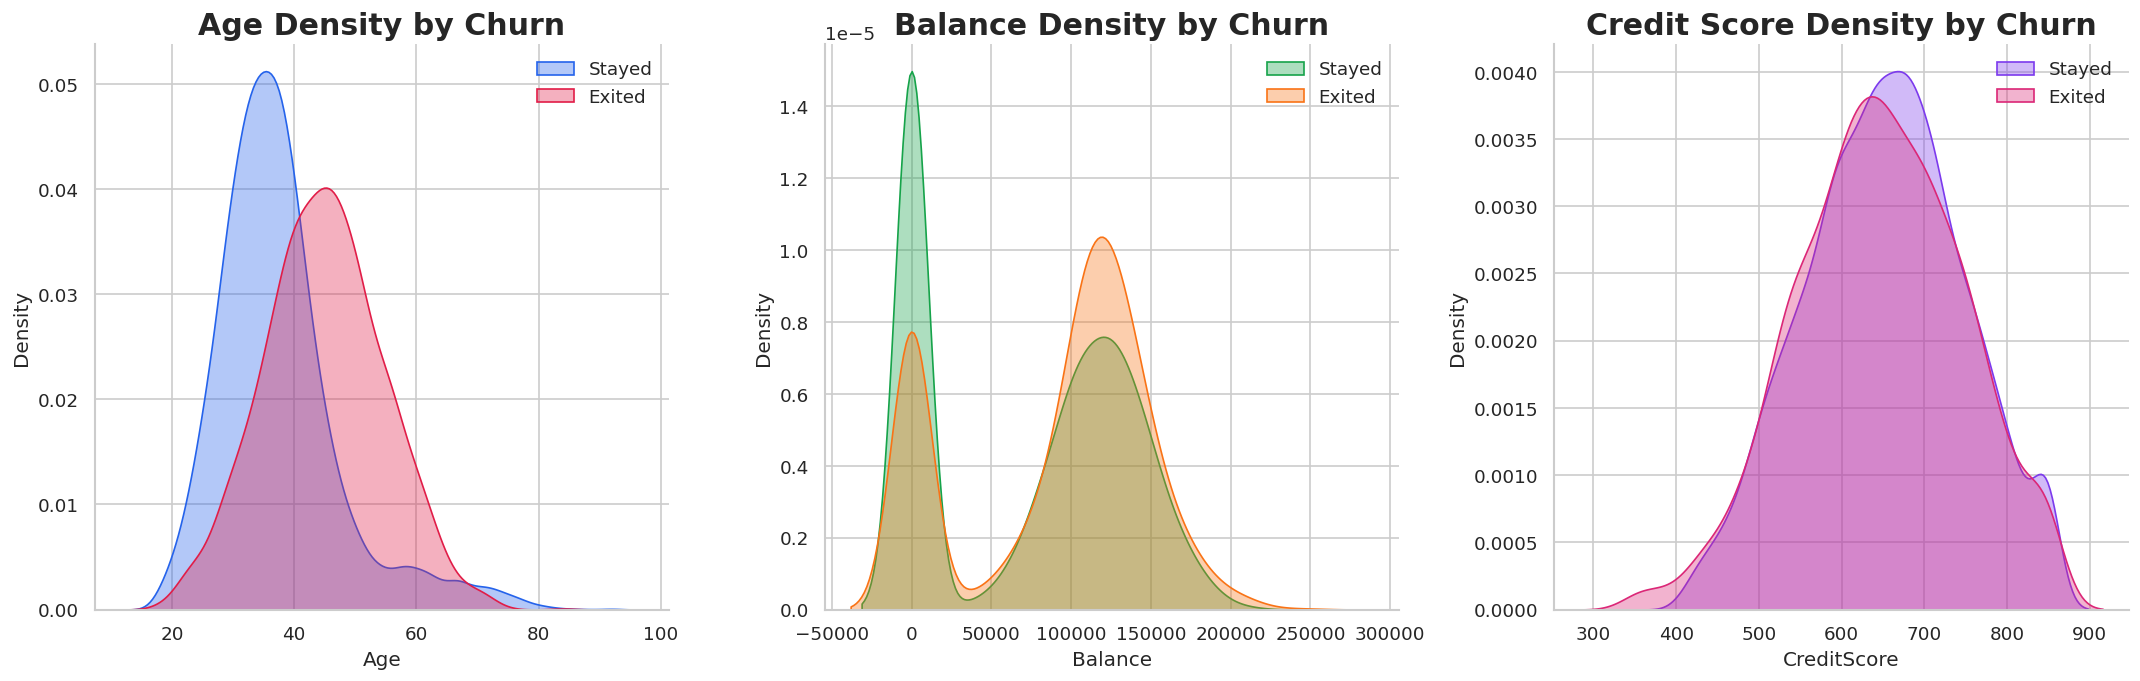

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.kdeplot(data=df_model[df_model["Exited"] == 0], x="Age", fill=True, alpha=0.35, color="#2563EB", label="Stayed", ax=axes[0])
sns.kdeplot(data=df_model[df_model["Exited"] == 1], x="Age", fill=True, alpha=0.35, color="#E11D48", label="Exited", ax=axes[0])
axes[0].set_title("Age Density by Churn")
axes[0].legend()

sns.kdeplot(data=df_model[df_model["Exited"] == 0], x="Balance", fill=True, alpha=0.35, color="#16A34A", label="Stayed", ax=axes[1])
sns.kdeplot(data=df_model[df_model["Exited"] == 1], x="Balance", fill=True, alpha=0.35, color="#F97316", label="Exited", ax=axes[1])
axes[1].set_title("Balance Density by Churn")
axes[1].legend()

sns.kdeplot(data=df_model[df_model["Exited"] == 0], x="CreditScore", fill=True, alpha=0.35, color="#7C3AED", label="Stayed", ax=axes[2])
sns.kdeplot(data=df_model[df_model["Exited"] == 1], x="CreditScore", fill=True, alpha=0.35, color="#DB2777", label="Exited", ax=axes[2])
axes[2].set_title("Credit Score Density by Churn")
axes[2].legend()

plt.tight_layout()
plt.show()


## 11. Churn Rate by Age Group, Tenure, Products and Activity

Grouping selected features makes the model-ready patterns easier to communicate to a non-technical audience.

In [18]:
df_model["AgeGroup"] = pd.cut(
    df_model["Age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

age_churn = df_model.groupby("AgeGroup", observed=True)["Exited"].mean().mul(100)
tenure_churn = df_model.groupby("Tenure")["Exited"].mean().mul(100)
product_churn = df_model.groupby("NumOfProducts")["Exited"].mean().mul(100)
activity_churn = df_model.groupby("IsActiveMember")["Exited"].mean().mul(100)

age_churn_table = age_churn.rename("Churn Rate (%)").to_frame()
tenure_churn_table = tenure_churn.rename("Churn Rate (%)").to_frame()
product_churn_table = product_churn.rename("Churn Rate (%)").to_frame()
activity_churn_table = activity_churn.rename("Churn Rate (%)").to_frame()

display(age_churn_table)
display(tenure_churn_table)
display(product_churn_table)
display(activity_churn_table)

,Churn Rate (%)
AgeGroup,
18-25,7.529
26-35,8.498
36-45,19.620
46-55,50.572
56-65,48.321
66+,13.258


,Churn Rate (%)
Tenure,
0,23.002
1,22.415
2,19.179
3,21.110
4,20.526
5,20.652
6,20.269
7,17.218
8,19.220


,Churn Rate (%)
NumOfProducts,
1,27.714
2,7.582
3,82.707
4,100.000


,Churn Rate (%)
IsActiveMember,
0,26.851
1,14.269


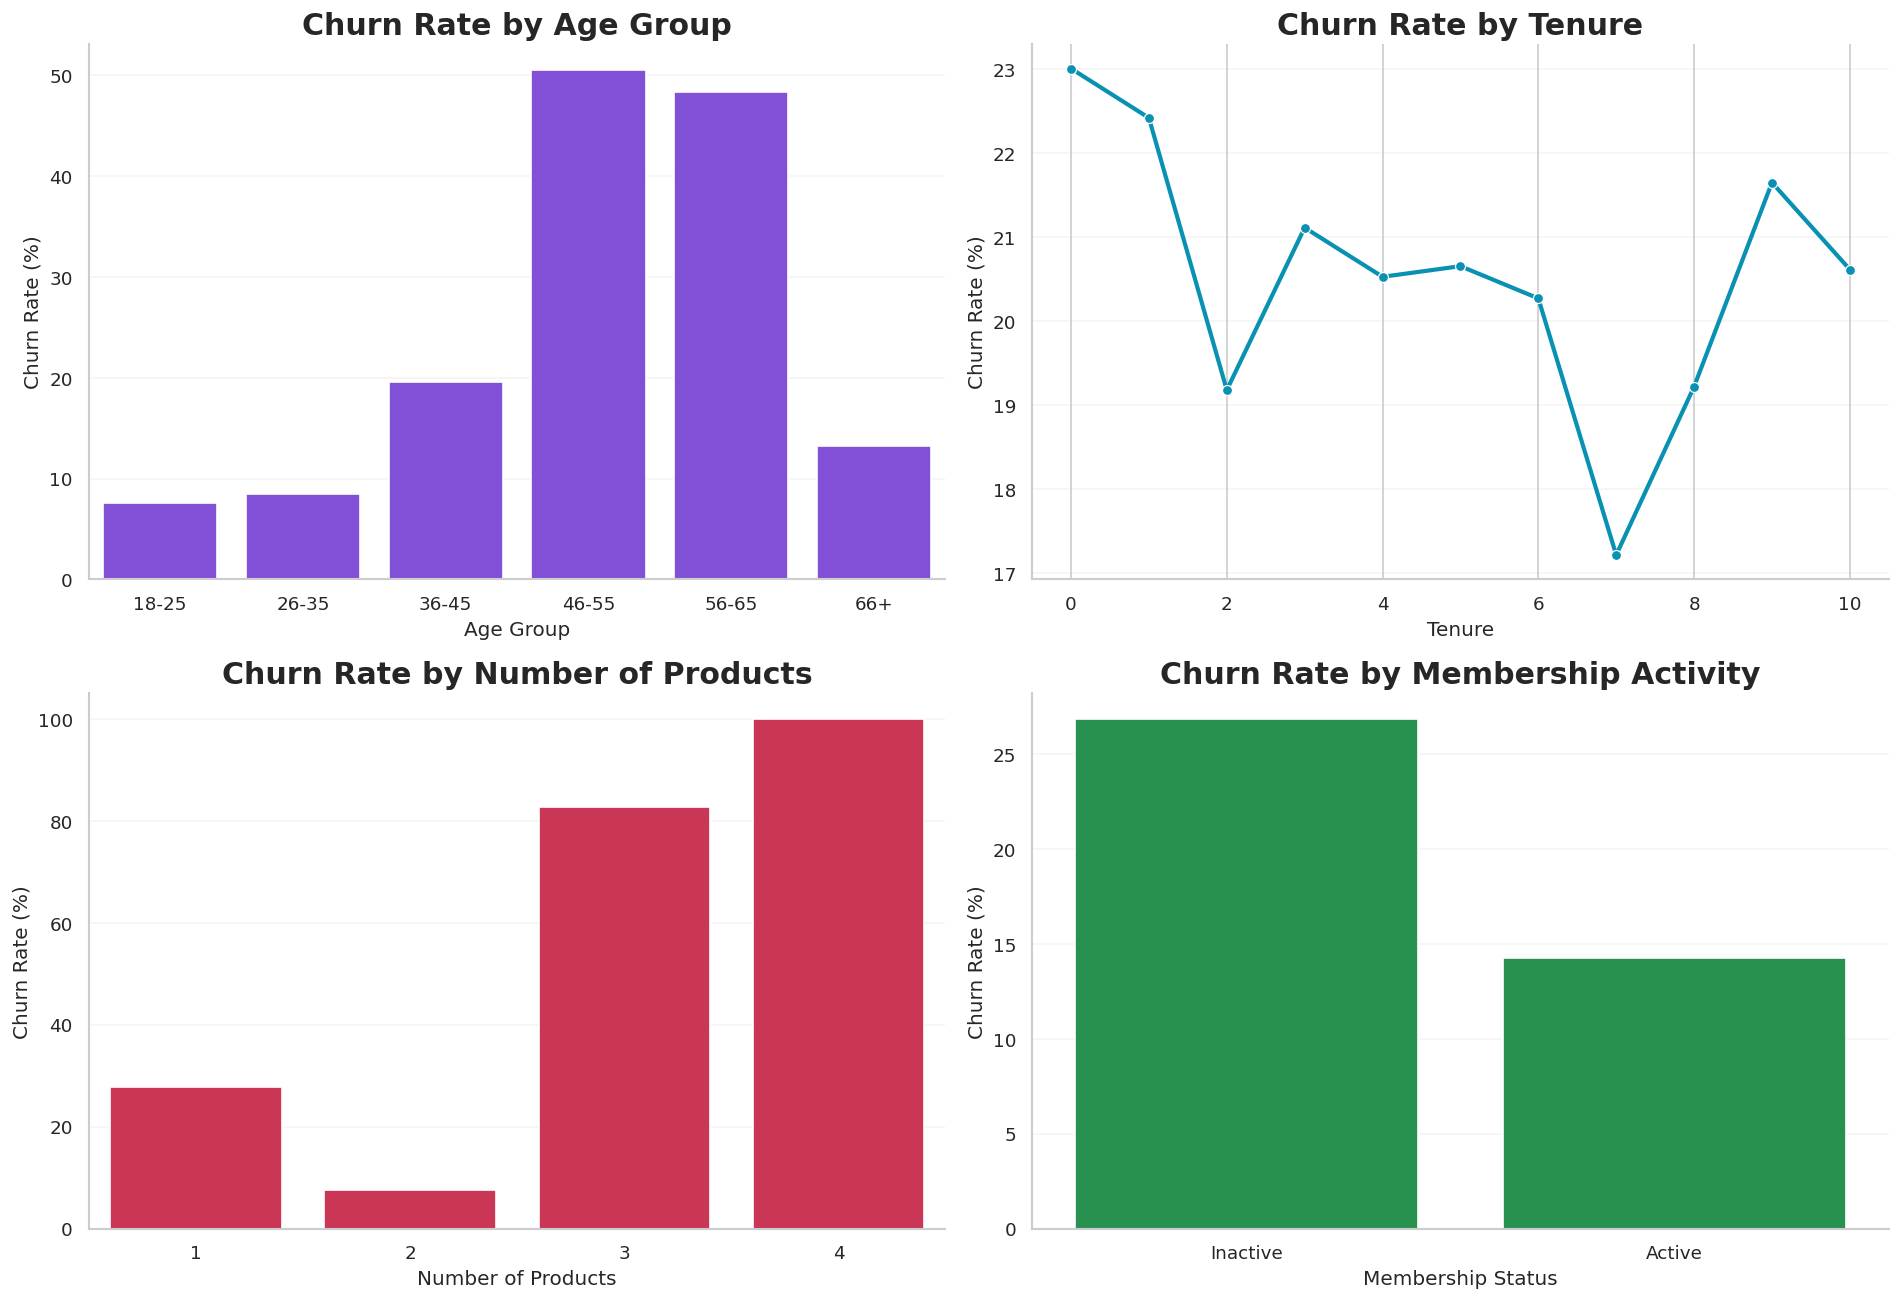

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(x=age_churn.index.astype(str), y=age_churn.values, ax=axes[0, 0], color="#7C3AED")
axes[0, 0].set_title("Churn Rate by Age Group")
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Churn Rate (%)")

sns.lineplot(x=tenure_churn.index, y=tenure_churn.values, marker="o", linewidth=2.5, ax=axes[0, 1], color="#0891B2")
axes[0, 1].set_title("Churn Rate by Tenure")
axes[0, 1].set_xlabel("Tenure")
axes[0, 1].set_ylabel("Churn Rate (%)")

sns.barplot(x=product_churn.index.astype(str), y=product_churn.values, ax=axes[1, 0], color="#E11D48")
axes[1, 0].set_title("Churn Rate by Number of Products")
axes[1, 0].set_xlabel("Number of Products")
axes[1, 0].set_ylabel("Churn Rate (%)")

activity_labels = ["Inactive", "Active"]
sns.barplot(x=activity_labels, y=activity_churn.values, ax=axes[1, 1], color="#16A34A")
axes[1, 1].set_title("Churn Rate by Membership Activity")
axes[1, 1].set_xlabel("Membership Status")
axes[1, 1].set_ylabel("Churn Rate (%)")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 12. Credit Card and Salary Analysis

These plots investigate whether credit-card ownership and estimated salary show visible differences in churn behavior. Association is not treated as causation.

,Churn Rate (%)
No Credit Card,20.815
Has Credit Card,20.184


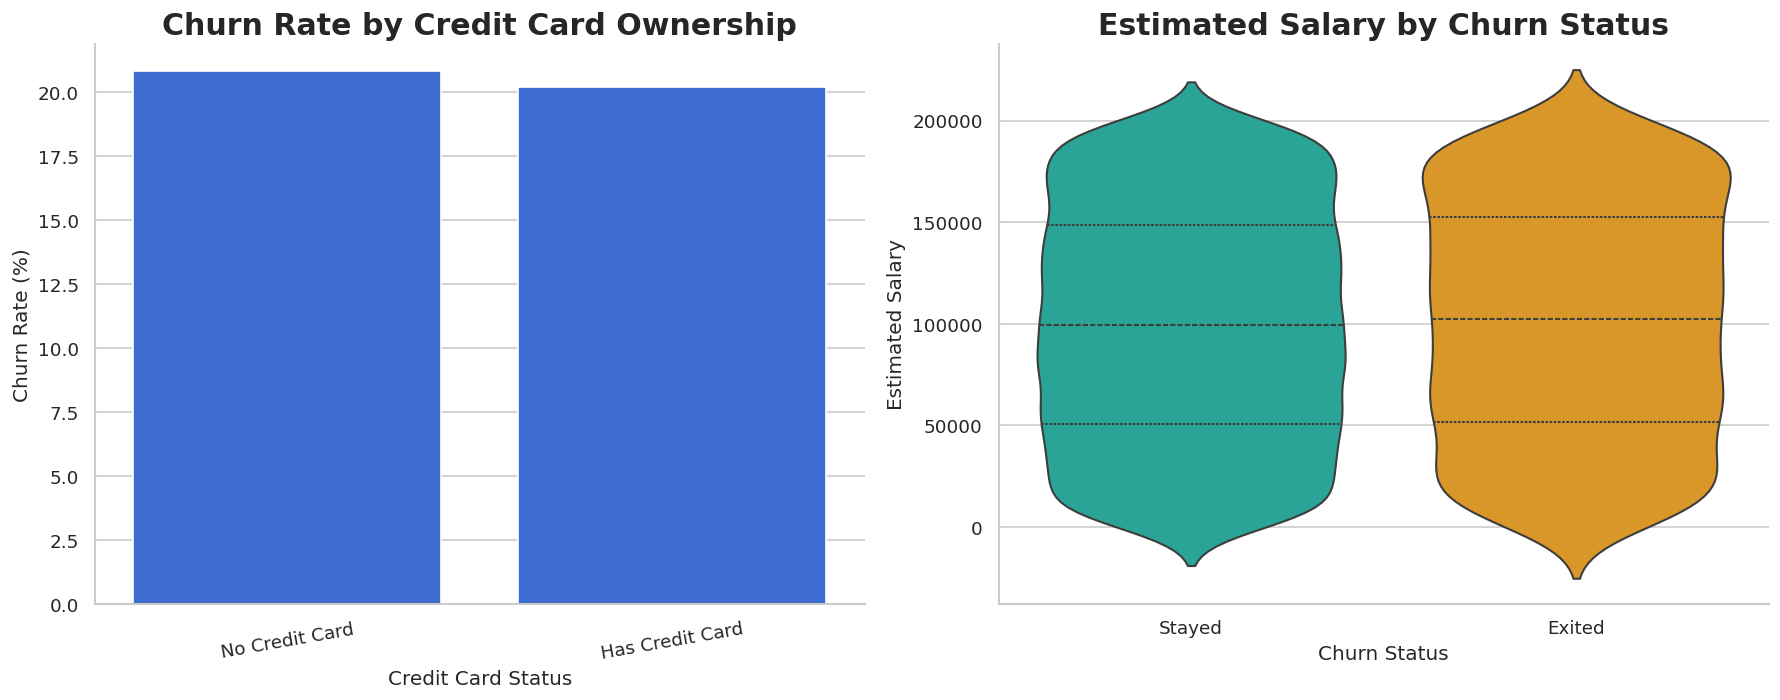

In [20]:
credit_card_churn = df_model.groupby("HasCrCard")["Exited"].mean().mul(100)
credit_card_table = credit_card_churn.rename("Churn Rate (%)").to_frame()
credit_card_table.index = ["No Credit Card", "Has Credit Card"]
display(credit_card_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=credit_card_table.index, y=credit_card_table["Churn Rate (%)"].values, ax=axes[0], color="#2563EB")
axes[0].set_title("Churn Rate by Credit Card Ownership")
axes[0].set_xlabel("Credit Card Status")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=10)

sns.violinplot(data=df_model, x="Exited", y="EstimatedSalary", ax=axes[1], hue="Exited", palette=["#14B8A6", "#F59E0B"], legend=False, inner="quartile")
axes[1].set_title("Estimated Salary by Churn Status")
axes[1].set_xticklabels(["Stayed", "Exited"])
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Estimated Salary")

plt.tight_layout()
plt.show()

## 13. Relationship Plots

Scatter plots provide a direct visual view of how several continuous variables overlap between the two churn classes.

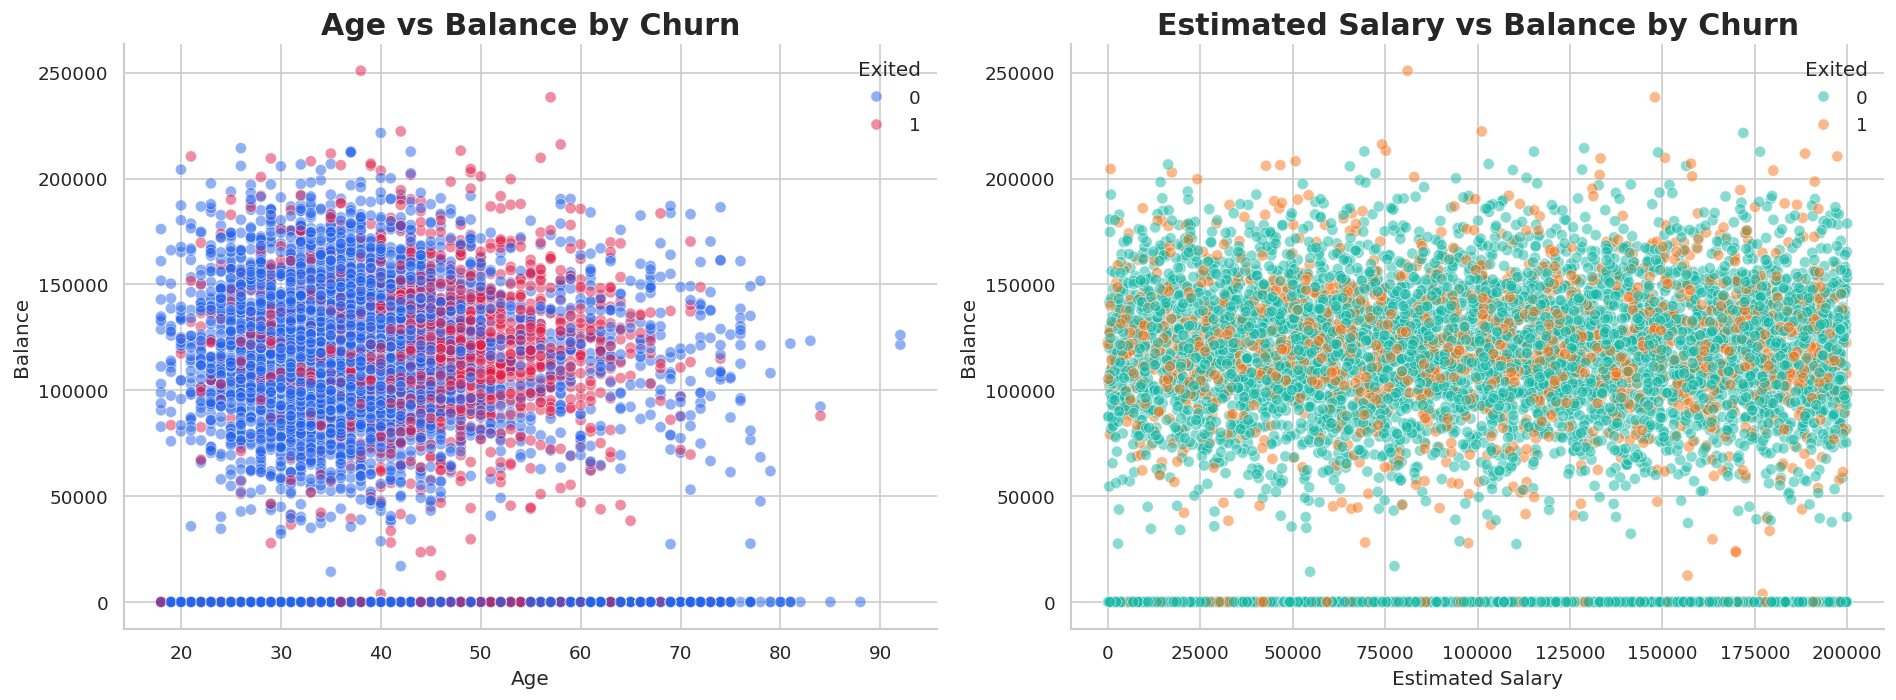

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_model, x="Age", y="Balance", hue="Exited", palette={0: "#2563EB", 1: "#E11D48"}, alpha=0.5, s=45, ax=axes[0])
axes[0].set_title("Age vs Balance by Churn")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Balance")

sns.scatterplot(data=df_model, x="EstimatedSalary", y="Balance", hue="Exited", palette={0: "#14B8A6", 1: "#F97316"}, alpha=0.5, s=45, ax=axes[1])
axes[1].set_title("Estimated Salary vs Balance by Churn")
axes[1].set_xlabel("Estimated Salary")
axes[1].set_ylabel("Balance")

plt.tight_layout()
plt.show()

## 14. Correlation Analysis

Correlation measures linear association among numerical variables. It is useful for understanding structure, but it does not prove causation and does not fully describe predictive power.

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000,-0.004,0.001,0.006,0.012,-0.005,0.026,-0.001,-0.027
Age,-0.004,1.000,-0.010,0.028,-0.031,-0.012,0.085,-0.007,0.285
Tenure,0.001,-0.010,1.000,-0.012,0.013,0.023,-0.028,0.008,-0.014
Balance,0.006,0.028,-0.012,1.000,-0.304,-0.015,-0.010,0.013,0.119
NumOfProducts,0.012,-0.031,0.013,-0.304,1.000,0.003,0.010,0.014,-0.048
HasCrCard,-0.005,-0.012,0.023,-0.015,0.003,1.000,-0.012,-0.010,-0.007
IsActiveMember,0.026,0.085,-0.028,-0.010,0.010,-0.012,1.000,-0.011,-0.156
EstimatedSalary,-0.001,-0.007,0.008,0.013,0.014,-0.010,-0.011,1.000,0.012
Exited,-0.027,0.285,-0.014,0.119,-0.048,-0.007,-0.156,0.012,1.000


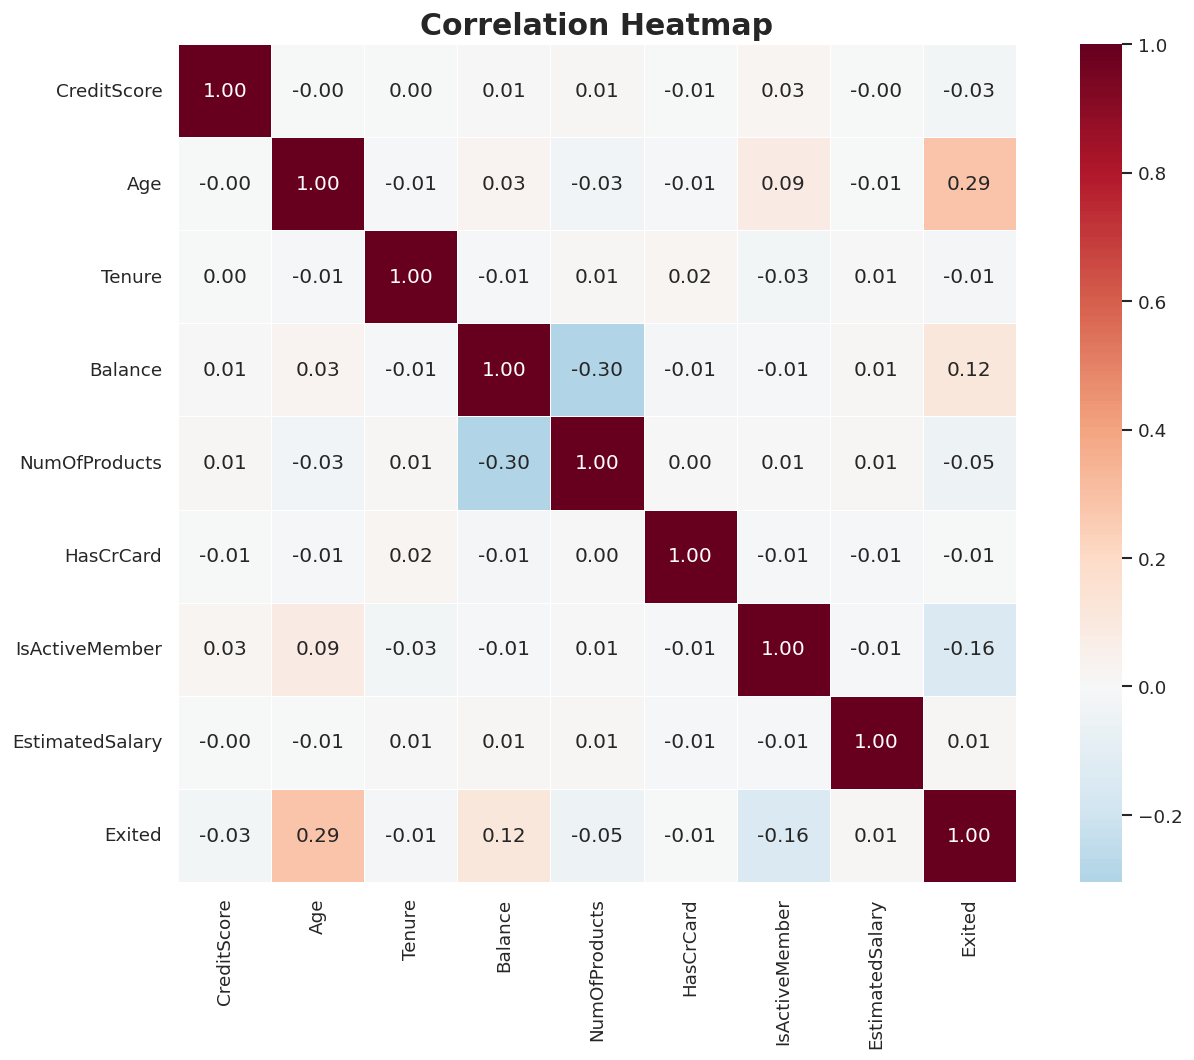

In [22]:
corr_columns = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
    "HasCrCard", "IsActiveMember", "EstimatedSalary", "Exited"
]

corr_matrix = df_model[corr_columns].corr()
display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, square=True, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 15. Prepare Features and Target

The `AgeGroup` column is useful for EDA but is not required by the model because the original continuous `Age` feature is already available. Geography and Gender are one-hot encoded before the train-test split.

In [23]:
model_data = df_model.drop(columns=["AgeGroup"]).copy()
model_data = pd.get_dummies(model_data, columns=["Geography", "Gender"], drop_first=True, dtype=int)

X = model_data.drop(columns=["Exited"])
y = model_data["Exited"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
display(X.head())

Feature matrix shape: (10000, 11)
Target vector shape: (10000,)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.000,1,1,1,"101,348.880",0,0,0
1,608,41,1,"83,807.860",1,0,1,"112,542.580",0,1,0
2,502,42,8,"159,660.800",3,1,0,"113,931.570",0,0,0
3,699,39,1,0.000,2,0,0,"93,826.630",0,0,0
4,850,43,2,"125,510.820",1,1,1,"79,084.100",0,1,0


## 16. Train-Test Split

A stratified split keeps the proportion of stayed and exited customers approximately consistent in both training and testing data.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training churn rate: {:.2f}%".format(y_train.mean() * 100))
print("Testing churn rate: {:.2f}%".format(y_test.mean() * 100))

Training samples: 8000
Testing samples: 2000
Training churn rate: 20.38%
Testing churn rate: 20.35%


## 17. Feature Scaling

Standardization transforms each feature using the mean and standard deviation learned from the training data. The test data is transformed using the same fitted scaler so information from the test set does not leak into training.

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)
print("Training feature means after scaling:", np.round(X_train_scaled.mean(axis=0)[:5], 3))
print("Training feature standard deviations after scaling:", np.round(X_train_scaled.std(axis=0)[:5], 3))

Scaled training shape: (8000, 11)
Scaled testing shape: (2000, 11)
Training feature means after scaling: [-0.  0. -0.  0. -0.]
Training feature standard deviations after scaling: [1. 1. 1. 1. 1.]


## 18. Logistic Regression Baseline

A simple baseline creates a reference point for the neural network. A deep learning model should improve on a meaningful baseline rather than being judged in isolation.

In [26]:
logistic_model = LogisticRegression(max_iter=2000, random_state=SEED, class_weight="balanced")
logistic_model.fit(X_train_scaled, y_train)

logistic_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]
logistic_prediction = (logistic_probability >= 0.50).astype(int)

logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_prediction),
    "Precision": precision_score(y_test, logistic_prediction, zero_division=0),
    "Recall": recall_score(y_test, logistic_prediction, zero_division=0),
    "F1 Score": f1_score(y_test, logistic_prediction, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, logistic_probability),
    "PR AUC": average_precision_score(y_test, logistic_probability)
}

display(pd.DataFrame(logistic_metrics.items(), columns=["Metric", "Score"]))

,Metric,Score
0,Accuracy,0.714
1,Precision,0.387
2,Recall,0.700
3,F1 Score,0.499
4,ROC AUC,0.777
5,PR AUC,0.468


## 19. Neural Network Architecture

The ANN uses dense layers with ReLU activation for nonlinear pattern learning, batch normalization for more stable optimization, dropout for regularization, and a sigmoid output unit for binary classification.

In [27]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 20. Class Weights

The churn class is usually the minority class. Class weights increase the training contribution of minority-class errors without duplicating records.

In [28]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)

Class weights: {np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}


## 21. Compile and Train the Neural Network

Early stopping restores the best validation-loss model, while learning-rate reduction allows the optimizer to make smaller updates after progress slows.

In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6269 - auc: 0.6653 - loss: 0.6699 - precision: 0.3002 - recall: 0.6183 - val_accuracy: 0.6012 - val_auc: 0.7847 - val_loss: 0.6385 - val_precision: 0.3129 - val_recall: 0.8313 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6731 - auc: 0.7525 - loss: 0.5927 - precision: 0.3506 - recall: 0.7008 - val_accuracy: 0.6938 - val_auc: 0.8255 - val_loss: 0.5381 - val_precision: 0.3754 - val_recall: 0.8000 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7039 - auc: 0.7933 - loss: 0.5538 - precision: 0.3846 - recall: 0.7443 - val_accuracy: 0.7294 - val_auc: 0.8408 - val_loss: 0.4971 - val_precision: 0.4096 - val_recall: 0.8000 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7303 - auc: 0.8137 - loss: 0.5322 - precision: 0.4152 - recall: 0.7771 - val_accuracy: 0.7369 - val_auc: 0.8465 - val_loss: 0.4955 -

## 22. Training History Dashboard

The training curves show whether the network is learning consistently and whether validation performance diverges from training performance.

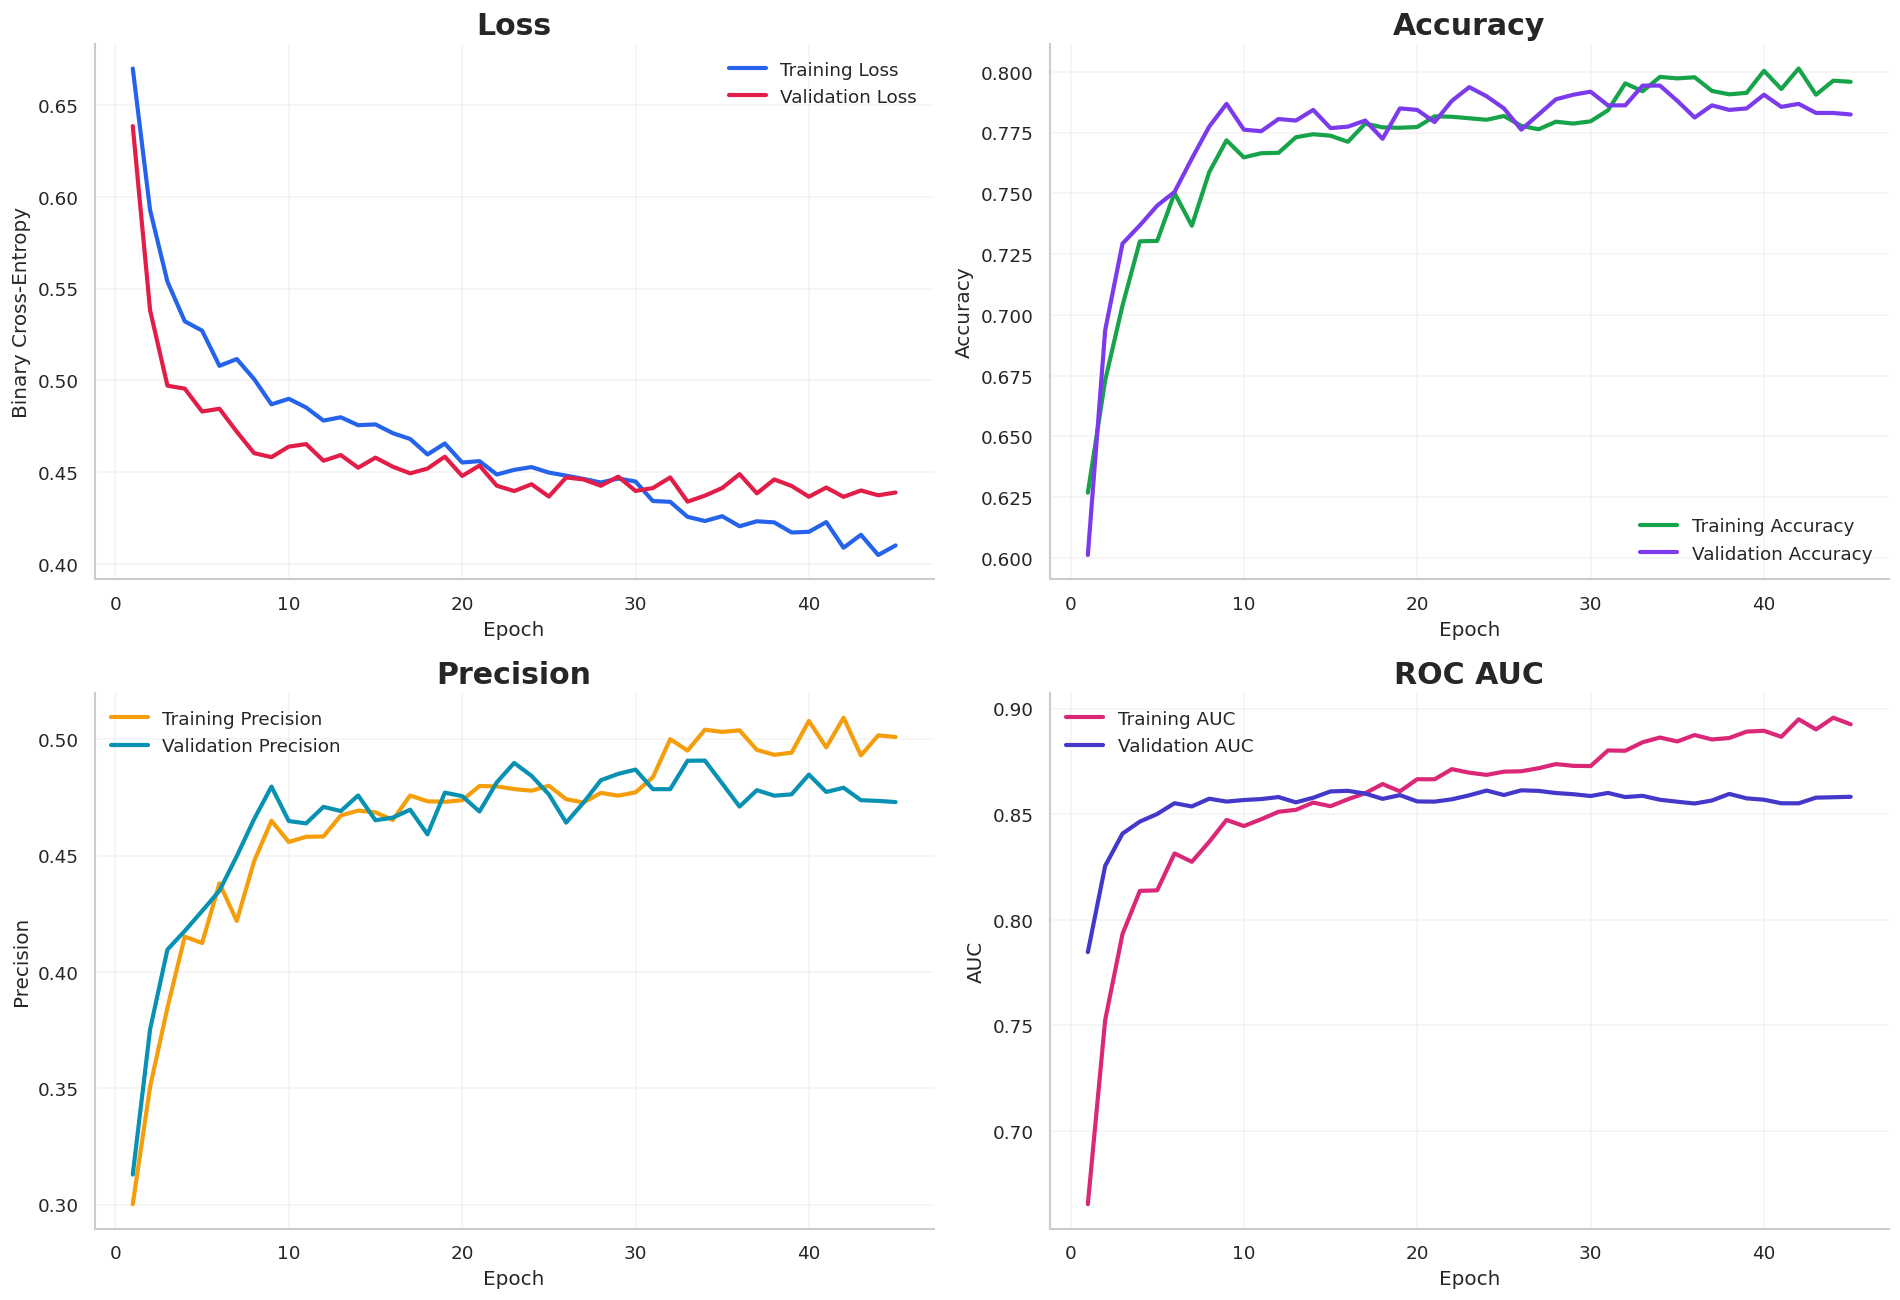

In [30]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].plot(history_df.index + 1, history_df["loss"], linewidth=2.5, label="Training Loss", color="#2563EB")
axes[0, 0].plot(history_df.index + 1, history_df["val_loss"], linewidth=2.5, label="Validation Loss", color="#E11D48")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Binary Cross-Entropy")
axes[0, 0].legend()

axes[0, 1].plot(history_df.index + 1, history_df["accuracy"], linewidth=2.5, label="Training Accuracy", color="#16A34A")
axes[0, 1].plot(history_df.index + 1, history_df["val_accuracy"], linewidth=2.5, label="Validation Accuracy", color="#7C3AED")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

axes[1, 0].plot(history_df.index + 1, history_df["precision"], linewidth=2.5, label="Training Precision", color="#F59E0B")
axes[1, 0].plot(history_df.index + 1, history_df["val_precision"], linewidth=2.5, label="Validation Precision", color="#0891B2")
axes[1, 0].set_title("Precision")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()

axes[1, 1].plot(history_df.index + 1, history_df["auc"], linewidth=2.5, label="Training AUC", color="#DB2777")
axes[1, 1].plot(history_df.index + 1, history_df["val_auc"], linewidth=2.5, label="Validation AUC", color="#4338CA")
axes[1, 1].set_title("ROC AUC")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("AUC")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 23. Evaluate the Neural Network

The final evaluation includes multiple classification metrics because churn prediction is more informative when recall and precision are considered alongside accuracy.

In [31]:
evaluation = model.evaluate(X_test_scaled, y_test, verbose=0, return_dict=True)
evaluation_table = pd.DataFrame(evaluation.items(), columns=["Metric", "Value"])
display(evaluation_table)

,Metric,Value
0,accuracy,0.781
1,auc,0.852
2,loss,0.445
3,precision,0.476
4,recall,0.740


In [32]:
y_probability = model.predict(X_test_scaled, verbose=0).ravel()
threshold = 0.50
y_pred = (y_probability >= threshold).astype(int)

ann_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_probability),
    "PR AUC": average_precision_score(y_test, y_probability)
}

comparison = pd.DataFrame({"Logistic Regression": logistic_metrics, "Neural Network": ann_metrics})
comparison["Neural Network Gain"] = comparison["Neural Network"] - comparison["Logistic Regression"]
display(comparison.round(4))

print(classification_report(y_test, y_pred, target_names=["Stayed", "Exited"], zero_division=0))

,Logistic Regression,Neural Network,Neural Network Gain
Accuracy,0.714,0.781,0.068
Precision,0.387,0.475,0.088
Recall,0.700,0.740,0.039
F1 Score,0.499,0.579,0.080
ROC AUC,0.777,0.853,0.075
PR AUC,0.468,0.697,0.229


              precision    recall  f1-score   support

      Stayed       0.92      0.79      0.85      1593
      Exited       0.48      0.74      0.58       407

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.83      0.78      0.80      2000



## 24. Model Comparison Chart

A side-by-side view makes it easier to see whether the neural network actually improves the baseline across the most important metrics.

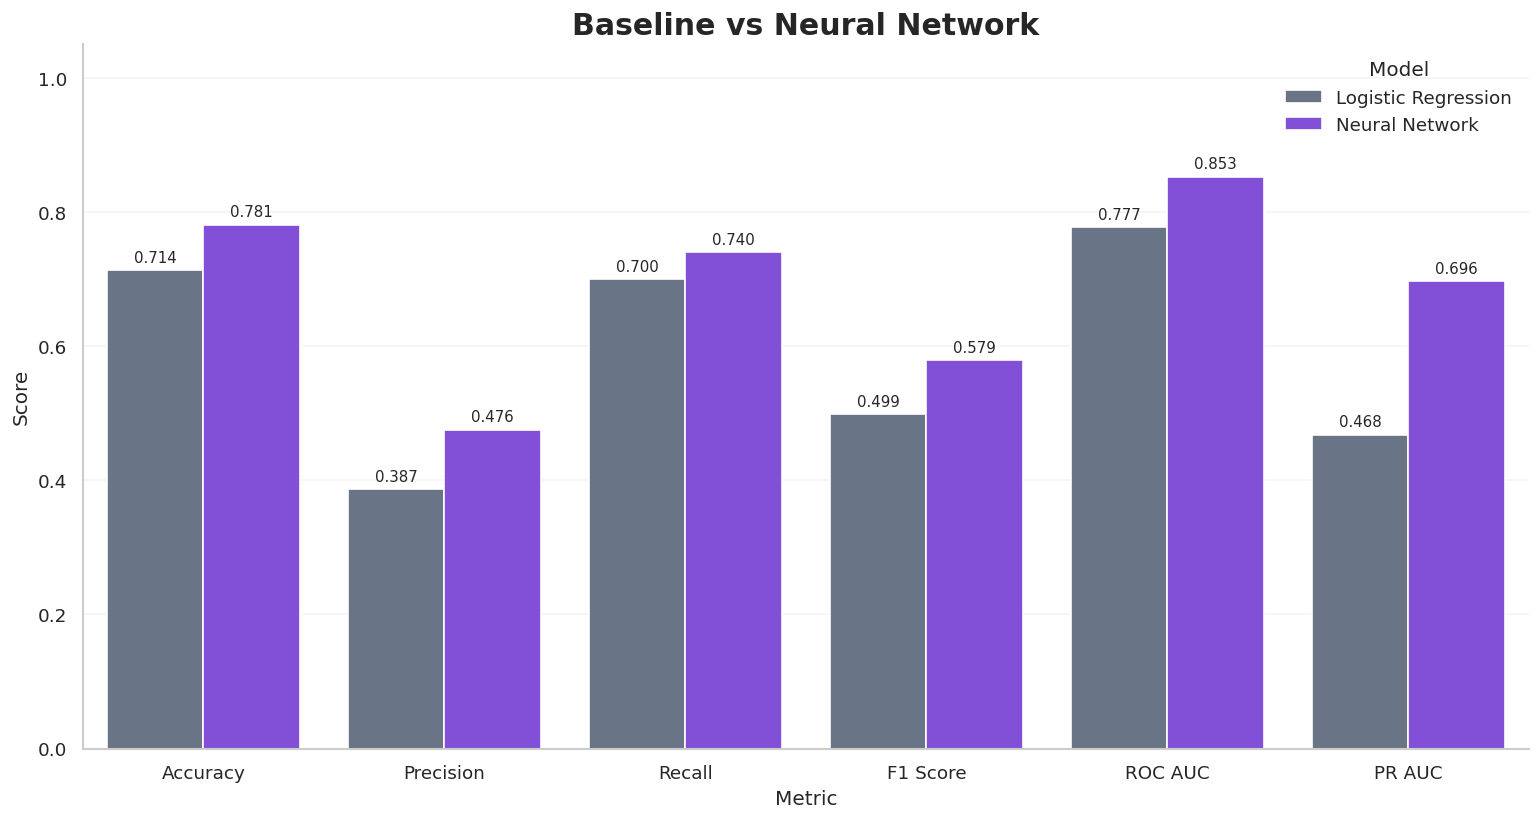

In [33]:
comparison_plot = pd.DataFrame({
    "Logistic Regression": logistic_metrics,
    "Neural Network": ann_metrics
})

plot_data = comparison_plot.reset_index().melt(id_vars="index", var_name="Model", value_name="Score")
plot_data = plot_data.rename(columns={"index": "Metric"})

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=plot_data, x="Metric", y="Score", hue="Model", palette=["#64748B", "#7C3AED"], ax=ax)
ax.set_title("Baseline vs Neural Network")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.grid(axis="y", alpha=0.2)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 25. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class. In churn prediction, false negatives can be especially important because they represent customers who were likely to churn but were classified as staying.

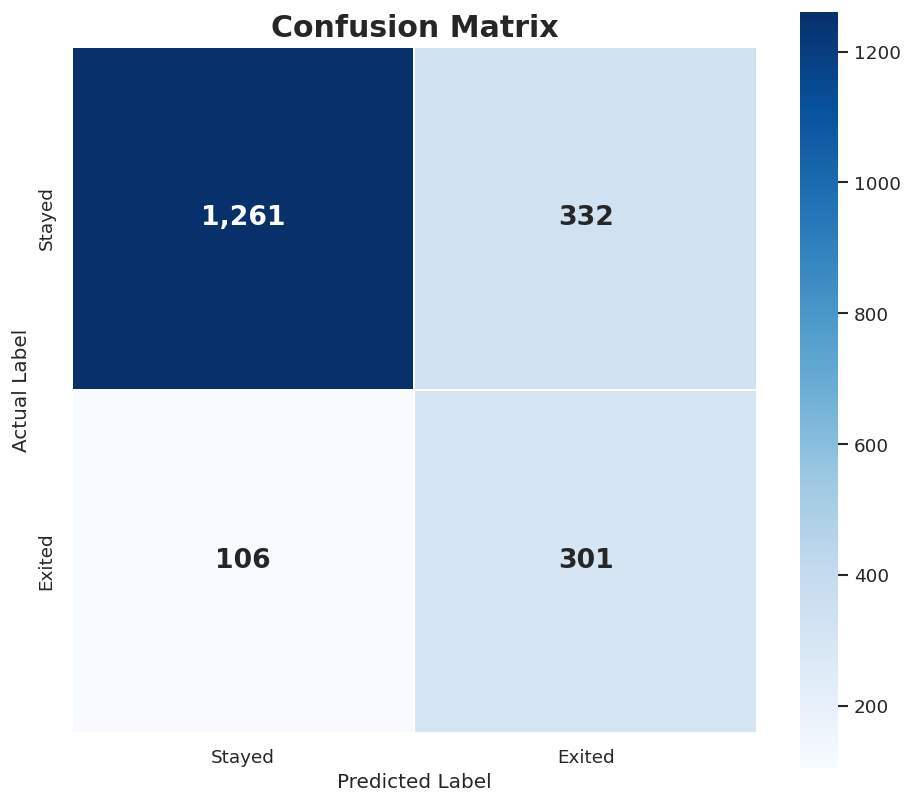

In [34]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Stayed", "Exited"],
    yticklabels=["Stayed", "Exited"],
    annot_kws={"fontsize": 16, "fontweight": "bold"},
    ax=ax
)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
plt.tight_layout()
plt.show()


## 26. ROC Curve and Precision-Recall Curve

ROC-AUC measures ranking quality across thresholds. Precision-Recall AUC is especially useful when the positive class is less common because it focuses on the quality of positive predictions.

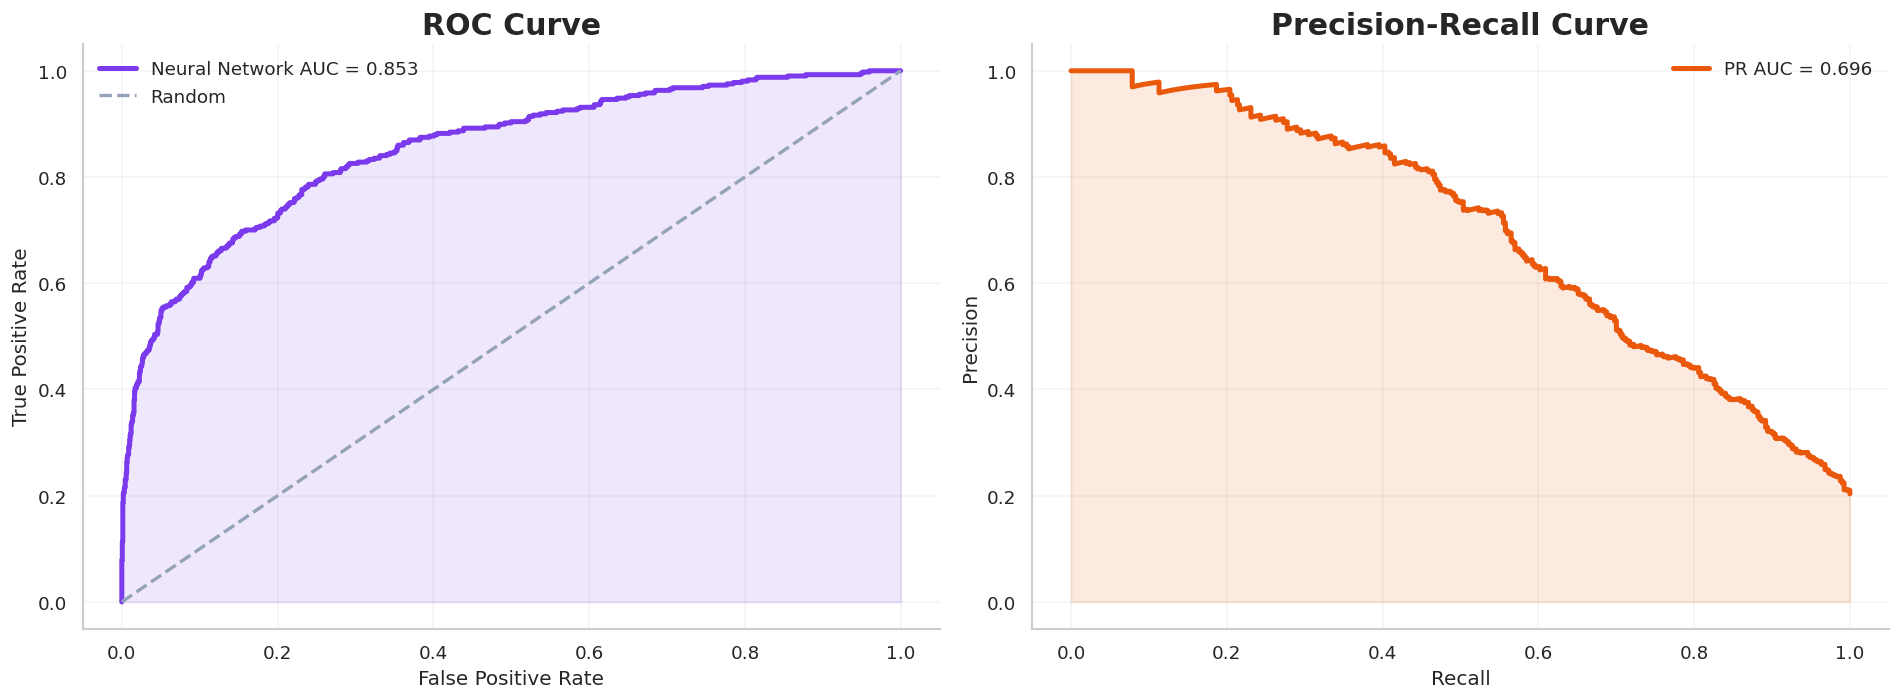

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_probability)
precision_values, recall_values, _ = precision_recall_curve(y_test, y_probability)
roc_auc = roc_auc_score(y_test, y_probability)
pr_auc = average_precision_score(y_test, y_probability)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, linewidth=3, color="#7C3AED", label=f"Neural Network AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=2, color="#94A3B8", label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.12, color="#7C3AED")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall_values, precision_values, linewidth=3, color="#EA580C", label=f"PR AUC = {pr_auc:.3f}")
axes[1].fill_between(recall_values, precision_values, alpha=0.12, color="#EA580C")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 27. Churn Probability Distribution

The neural network produces probabilities between 0 and 1. The classification threshold converts these probabilities into the final `Stayed` or `Exited` labels.

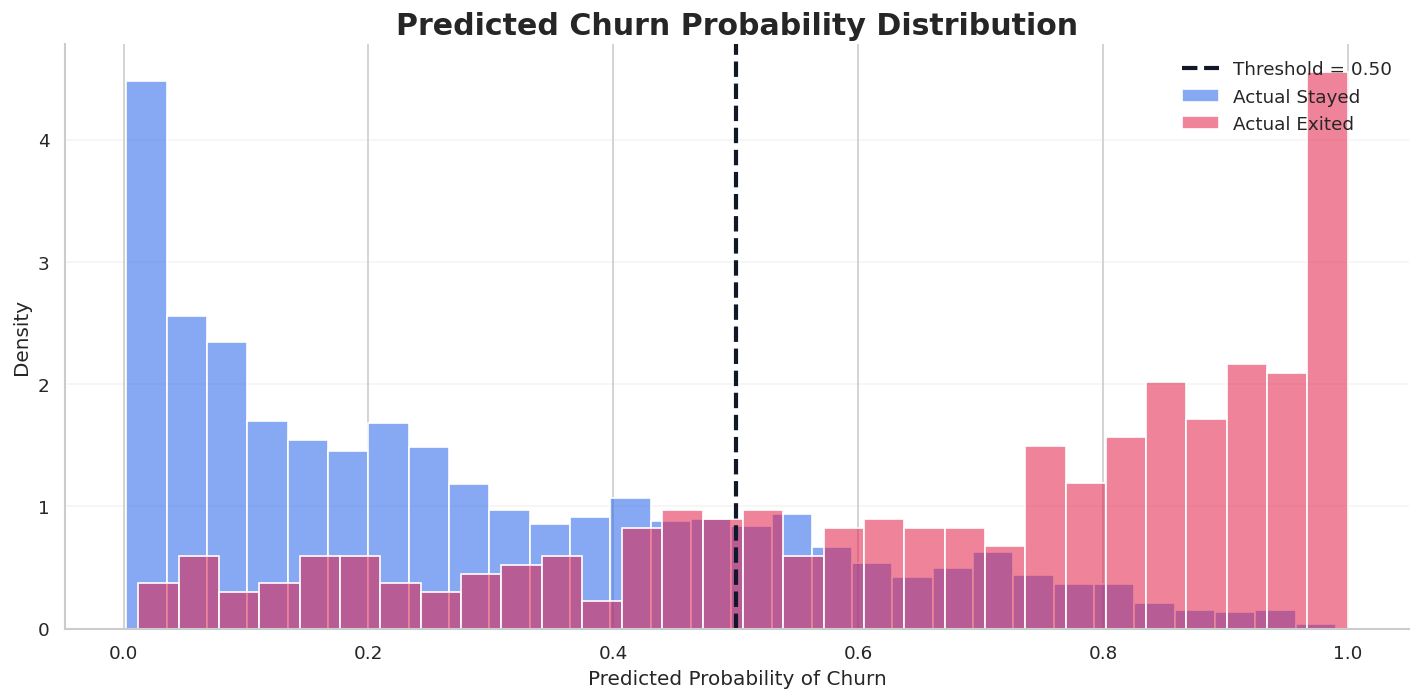

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(y_probability[y_test.values == 0], bins=30, stat="density", alpha=0.55, color="#2563EB", label="Actual Stayed", ax=ax)
sns.histplot(y_probability[y_test.values == 1], bins=30, stat="density", alpha=0.55, color="#E11D48", label="Actual Exited", ax=ax)
ax.axvline(threshold, linestyle="--", linewidth=2.5, color="#111827", label=f"Threshold = {threshold:.2f}")
ax.set_title("Predicted Churn Probability Distribution")
ax.set_xlabel("Predicted Probability of Churn")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 28. Threshold Optimization

A 0.50 threshold is a default, not a law. We evaluate several thresholds and select the threshold with the strongest F1 score. This balances precision and recall for the positive churn class.

In [37]:
thresholds = np.arange(0.10, 0.91, 0.02)
threshold_rows = []

for current_threshold in thresholds:
    current_prediction = (y_probability >= current_threshold).astype(int)
    threshold_rows.append({
        "Threshold": current_threshold,
        "Accuracy": accuracy_score(y_test, current_prediction),
        "Precision": precision_score(y_test, current_prediction, zero_division=0),
        "Recall": recall_score(y_test, current_prediction, zero_division=0),
        "F1 Score": f1_score(y_test, current_prediction, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.loc[threshold_df["F1 Score"].idxmax(), "Threshold"]

display(threshold_df.round(3))
print(f"Best F1 threshold: {best_threshold:.2f}")

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.100,0.440,0.262,0.963,0.412
1,0.120,0.466,0.270,0.953,0.421
2,0.140,0.492,0.279,0.946,0.431
3,0.160,0.514,0.287,0.931,0.438
4,0.180,0.535,0.295,0.924,0.447
5,0.200,0.556,0.304,0.916,0.456
6,0.220,0.584,0.316,0.902,0.468
7,0.240,0.602,0.326,0.894,0.478
8,0.260,0.628,0.341,0.892,0.494
9,0.280,0.642,0.350,0.882,0.501


Best F1 threshold: 0.74


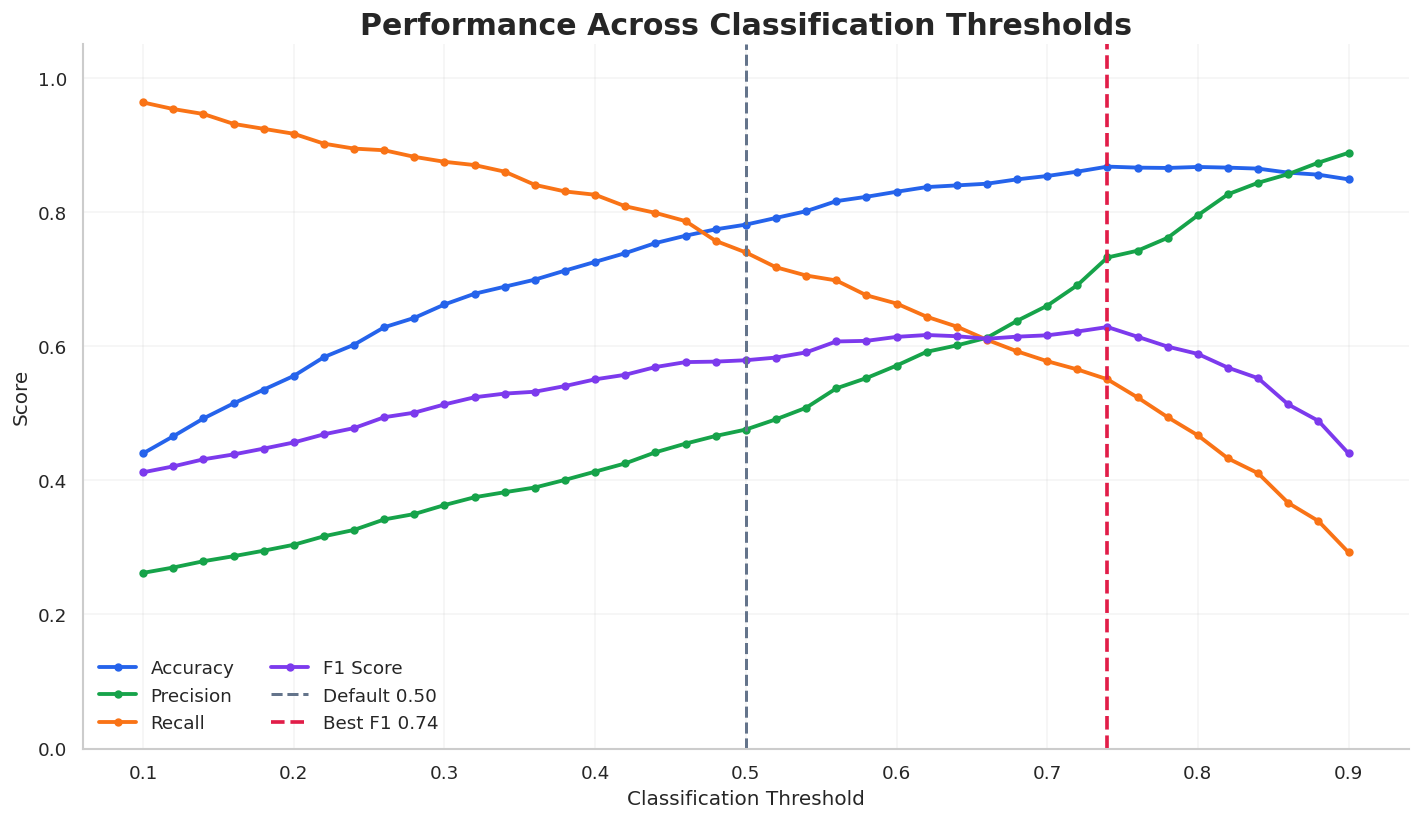

In [38]:
fig, ax = plt.subplots(figsize=(12, 7))

for metric, color in [("Accuracy", "#2563EB"), ("Precision", "#16A34A"), ("Recall", "#F97316"), ("F1 Score", "#7C3AED")]:
    ax.plot(threshold_df["Threshold"], threshold_df[metric], marker="o", linewidth=2.3, markersize=4, label=metric, color=color)

ax.axvline(0.50, linestyle="--", linewidth=1.8, color="#64748B", label="Default 0.50")
ax.axvline(best_threshold, linestyle="--", linewidth=2.2, color="#E11D48", label=f"Best F1 {best_threshold:.2f}")
ax.set_title("Performance Across Classification Thresholds")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [39]:
optimized_prediction = (y_probability >= best_threshold).astype(int)
optimized_metrics = {
    "Accuracy": accuracy_score(y_test, optimized_prediction),
    "Precision": precision_score(y_test, optimized_prediction, zero_division=0),
    "Recall": recall_score(y_test, optimized_prediction, zero_division=0),
    "F1 Score": f1_score(y_test, optimized_prediction, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_probability),
    "PR AUC": average_precision_score(y_test, y_probability)
}

display(pd.DataFrame({"Default Threshold 0.50": ann_metrics, "Optimized Threshold": optimized_metrics}).round(4))

,Default Threshold 0.50,Optimized Threshold
Accuracy,0.781,0.868
Precision,0.475,0.732
Recall,0.740,0.550
F1 Score,0.579,0.628
ROC AUC,0.853,0.853
PR AUC,0.697,0.697


## 29. Permutation Feature Importance

Permutation importance measures how much model performance decreases when one feature is randomly shuffled. Larger decreases suggest the model relied more heavily on that feature for its predictions.

In [40]:
base_auc = roc_auc_score(y_test, model.predict(X_test_scaled, verbose=0).ravel())
importance_rows = []
rng = np.random.default_rng(SEED)

for column_index, feature_name in enumerate(X.columns):
    shuffled_scores = []
    for _ in range(5):
        shuffled = X_test_scaled.copy()
        shuffled[:, column_index] = rng.permutation(shuffled[:, column_index])
        shuffled_probability = model.predict(shuffled, verbose=0).ravel()
        shuffled_scores.append(roc_auc_score(y_test, shuffled_probability))
    importance_rows.append({
        "Feature": feature_name,
        "Importance": base_auc - np.mean(shuffled_scores)
    })

feature_importance = pd.DataFrame(importance_rows).sort_values("Importance", ascending=False)
display(feature_importance)

,Feature,Importance
4,NumOfProducts,0.133
1,Age,0.113
6,IsActiveMember,0.028
8,Geography_Germany,0.026
3,Balance,0.023
10,Gender_Male,0.008
9,Geography_Spain,0.001
0,CreditScore,0.000
5,HasCrCard,0.000
7,EstimatedSalary,-0.000


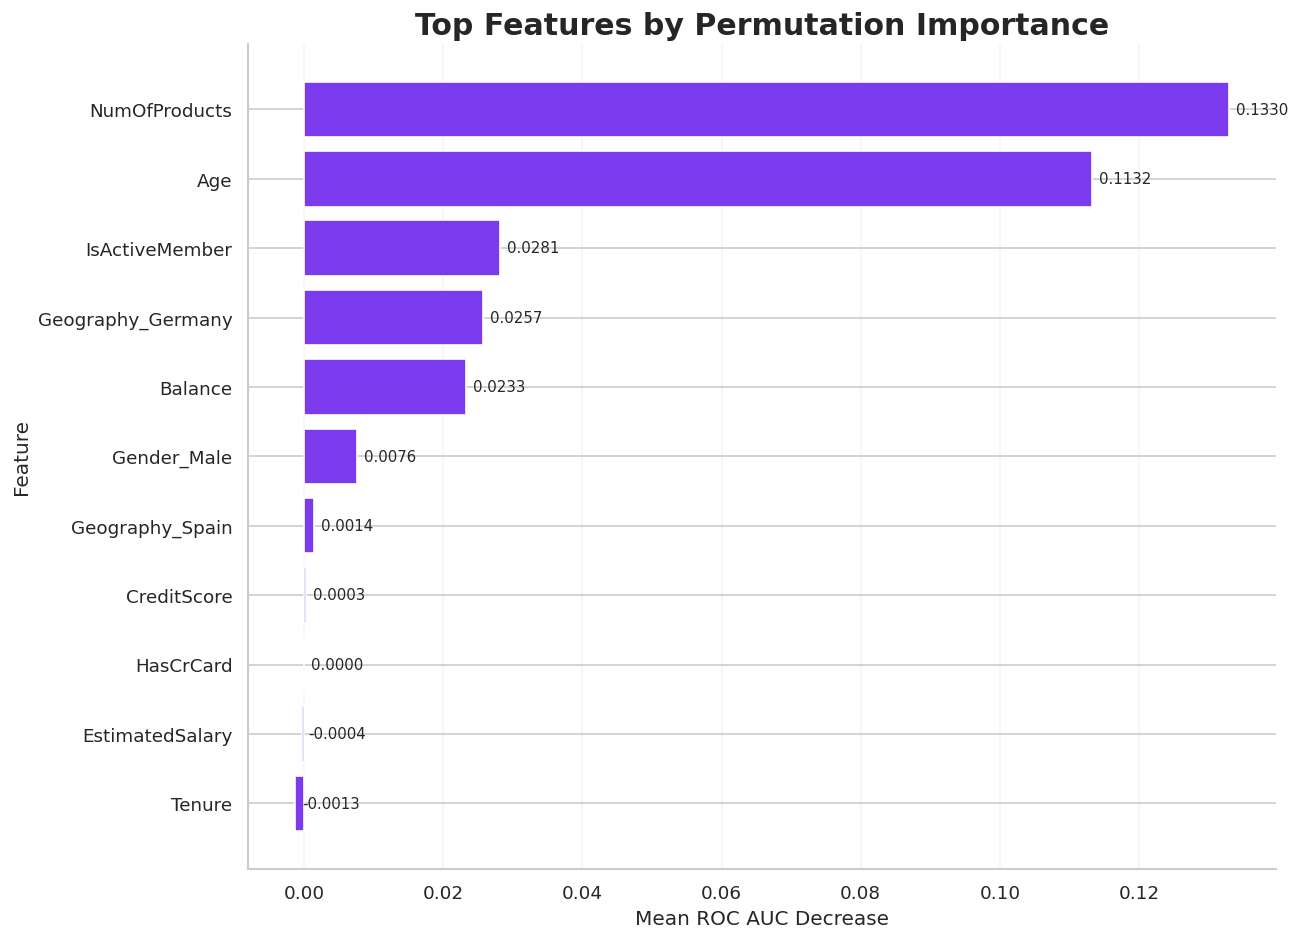

In [41]:
top_features = feature_importance.head(12).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top_features["Feature"], top_features["Importance"], color="#7C3AED")
ax.set_title("Top Features by Permutation Importance")
ax.set_xlabel("Mean ROC AUC Decrease")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.2)

for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 30. Final Model Performance Dashboard

This compact dashboard summarizes the most important model metrics and the optimized threshold selected from the test-set threshold analysis.

,Metric,Score
0,Accuracy,0.868
1,Precision,0.732
2,Recall,0.550
3,F1 Score,0.628
4,ROC AUC,0.853
5,PR AUC,0.696


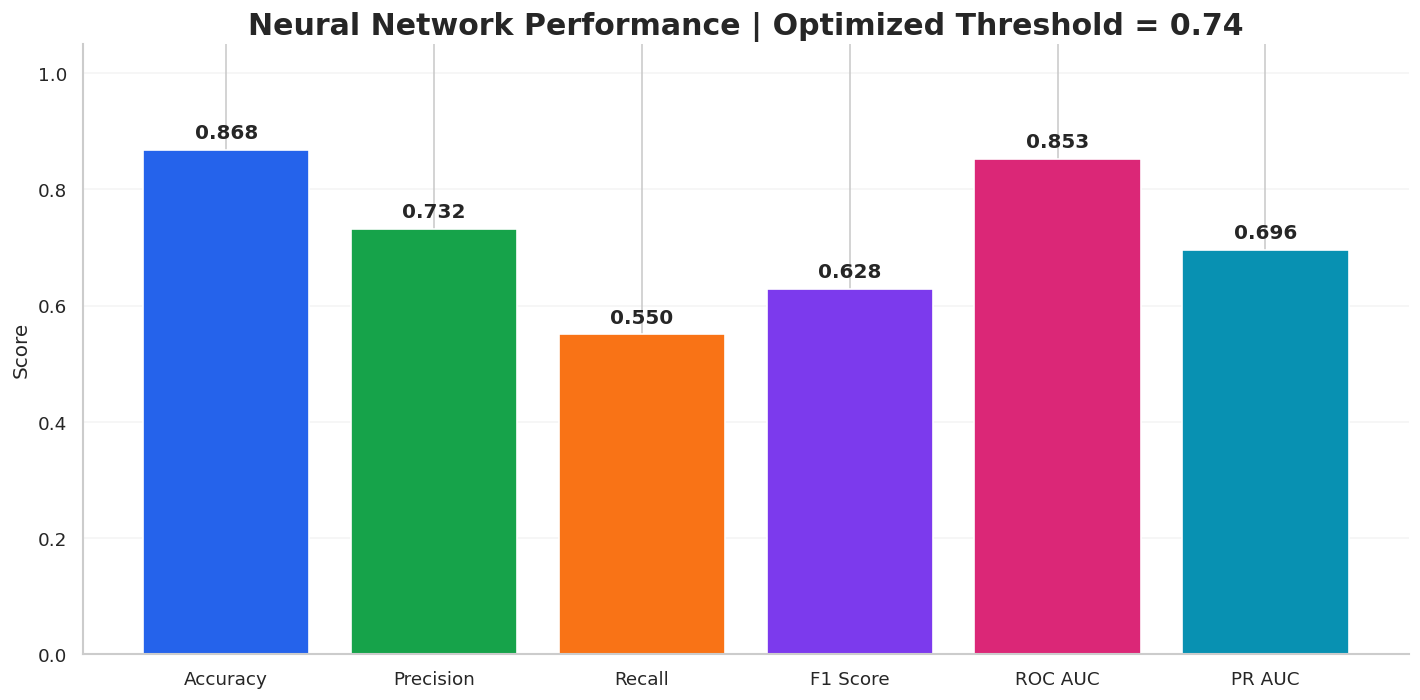

In [42]:
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"],
    "Score": [
        optimized_metrics["Accuracy"],
        optimized_metrics["Precision"],
        optimized_metrics["Recall"],
        optimized_metrics["F1 Score"],
        optimized_metrics["ROC AUC"],
        optimized_metrics["PR AUC"]
    ]
})

display(final_metrics.style.format({"Score": "{:.3f}"}).bar(subset=["Score"], color="#C4B5FD"))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(final_metrics["Metric"], final_metrics["Score"], color=["#2563EB", "#16A34A", "#F97316", "#7C3AED", "#DB2777", "#0891B2"])
ax.set_title(f"Neural Network Performance | Optimized Threshold = {best_threshold:.2f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, final_metrics["Score"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 31. Reusable Customer Churn Prediction Function

This function accepts one customer's attributes, applies the exact same encoding and scaling logic used during training, and returns a churn probability, predicted class, and business-friendly risk category.

In [43]:
feature_columns = X.columns.tolist()

required_columns = [
    "CreditScore", "Geography", "Gender", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"
]

def predict_customer_churn(customer_data, model=model, scaler=scaler, feature_columns=feature_columns, threshold=best_threshold):
    missing = [column for column in required_columns if column not in customer_data]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    customer_df = pd.DataFrame([customer_data])
    customer_encoded = pd.get_dummies(customer_df, columns=["Geography", "Gender"], drop_first=True, dtype=int)
    customer_encoded = customer_encoded.reindex(columns=feature_columns, fill_value=0)
    customer_scaled = scaler.transform(customer_encoded)

    probability = float(model.predict(customer_scaled, verbose=0).ravel()[0])
    prediction = int(probability >= threshold)

    if probability < 0.30:
        risk_category = "Low Risk"
    elif probability < 0.60:
        risk_category = "Medium Risk"
    else:
        risk_category = "High Risk"

    return pd.DataFrame([{
        "Churn Probability": probability,
        "Predicted Class": prediction,
        "Prediction": "Exited" if prediction == 1 else "Stayed",
        "Risk Category": risk_category,
        "Decision Threshold": threshold
    }])


## 32. Example Customer Prediction

The example below can be replaced with real customer values. The model returns a probability rather than only a yes/no answer, which makes it possible to rank customers by churn risk.


In [44]:
example_customer = {
    "CreditScore": 620,
    "Geography": "Germany",
    "Gender": "Female",
    "Age": 45,
    "Tenure": 3,
    "Balance": 110000.0,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 85000.0
}

prediction_result = predict_customer_churn(example_customer)
display(prediction_result.style.format({"Churn Probability": "{:.2%}", "Decision Threshold": "{:.2f}"}))

,Churn Probability,Predicted Class,Prediction,Risk Category,Decision Threshold
0,45.86%,0,Stayed,Medium Risk,0.74


## 33. Business Interpretation

The analysis should be interpreted as predictive association rather than proof of causality. The strongest feature-importance results indicate which variables the trained model relied on most for ranking churn risk.

A practical retention workflow can use the predicted probability to prioritize outreach:

- **Low Risk:** normal engagement strategy
- **Medium Risk:** proactive engagement and account review
- **High Risk:** targeted retention intervention

The threshold can be changed when the business cost of false negatives and false positives is known.

## 34. Final Conclusions

This project combines exploratory analysis, classical machine learning, and deep learning in one reproducible workflow.

### Key outcomes

- The dataset was audited for missing values, duplicates, data types, categories, and numerical ranges.
- Identifier columns were removed before modeling.
- Churn behavior was explored across geography, gender, age, balance, credit score, tenure, product count, activity, credit-card ownership, and salary.
- Categorical variables were one-hot encoded and numerical inputs were standardized using training data only.
- Logistic Regression provided a transparent baseline.
- The TensorFlow/Keras ANN modeled nonlinear relationships and was evaluated with several complementary metrics.
- Threshold analysis demonstrated why 0.50 is only a default classification threshold.
- Permutation importance provided a practical view of which features influenced model ranking.
- The final notebook includes a reusable function for individual customer churn prediction.